# Mass Model — $\mathcal{P}(P_\mathrm{rot}\,|\,m, \sigma_m, \tau)$


Flow $x$ (density variable): `log_prot`  
Conditioning vector: `[log_age_myr, mass_msun, mass_msun_err_lo, mass_msun_err_hi]`  

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib.pyplot as plt

from training.constants import LOGA_GRID
from training.data      import load_training, make_holdout_split
from training.kfold     import run_kfold
from training.plots     import set_paper_style, plot_posteriors_by_age
from training.report    import training_report, kfold_report, prot_space_report

set_paper_style()

## 1. Load data

In [2]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=False)

train_val_df, test_df = make_holdout_split(df, test_frac=0.10)

print(f'Total stars     : {len(df)}')
print(f'Train/val pool  : {len(train_val_df)}  ({len(train_val_df)/len(df)*100:.1f}%)')
print(f'Test holdout    : {len(test_df)}  ({len(test_df)/len(df)*100:.1f}%)')
print()
print('Test set age distribution (log10 Myr):')
print(test_df['log_age_myr'].describe().round(3))

Total stars     : 6128
Train/val pool  : 5515  (90.0%)
Test holdout    : 613  (10.0%)

Test set age distribution (log10 Myr):
count    613.000
mean       2.113
std        0.651
min        0.196
25%        1.653
50%        2.105
75%        2.600
max        3.999
Name: log_age_myr, dtype: float64


## 2. Define conditioning columns

In [3]:
OBS_COL     = 'log_prot'
COND_COLS   = ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
N_FOLDS     = 5
TOTAL_STEPS = 10000
N_SAMPLES   = 10

# Full grid: 3 architectures x 4 batch sizes, all OneCycleLR
ARCHS = [
    dict(name='baseline', hidden_features=(64,  64)),
    dict(name='2xlayers', hidden_features=(64,  64, 64, 64)),
    dict(name='2xwidth',  hidden_features=(128, 128)),
]
BATCH_SIZES = [16, 32, 64, 128]

CONFIGS = [
    dict(name=f"{a['name']}_b{b}",
         hidden_features=a['hidden_features'],
         use_onecycle=True,
         batch_size=b)
    for a in ARCHS
    for b in BATCH_SIZES
]

print(f'Conditioning vector ({len(COND_COLS)}): {COND_COLS}')
print(f'Total steps: {TOTAL_STEPS}  |  Age samples: {N_SAMPLES}')
print(f'Configs to sweep: {len(CONFIGS)}')
n_train_approx = int(len(train_val_df) * 0.8)
for cfg in CONFIGS:
    spe = max(1, n_train_approx // cfg['batch_size'])
    print(f"  {cfg['name']:25s}  batch={cfg['batch_size']:4d}  ~{spe:4d} steps/epoch  ~{TOTAL_STEPS // spe:4d} epochs")


Conditioning vector (4): ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
Total steps: 10000  |  Age samples: 10
Configs to sweep: 12
  baseline_b16               batch=  16  ~ 275 steps/epoch  ~  36 epochs
  baseline_b32               batch=  32  ~ 137 steps/epoch  ~  72 epochs
  baseline_b64               batch=  64  ~  68 steps/epoch  ~ 147 epochs
  baseline_b128              batch= 128  ~  34 steps/epoch  ~ 294 epochs
  2xlayers_b16               batch=  16  ~ 275 steps/epoch  ~  36 epochs
  2xlayers_b32               batch=  32  ~ 137 steps/epoch  ~  72 epochs
  2xlayers_b64               batch=  64  ~  68 steps/epoch  ~ 147 epochs
  2xlayers_b128              batch= 128  ~  34 steps/epoch  ~ 294 epochs
  2xwidth_b16                batch=  16  ~ 275 steps/epoch  ~  36 epochs
  2xwidth_b32                batch=  32  ~ 137 steps/epoch  ~  72 epochs
  2xwidth_b64                batch=  64  ~  68 steps/epoch  ~ 147 epochs
  2xwidth_b128               batch= 128  ~ 

## 3. K-fold sweep

In [4]:
sweep_results = {}

for cfg in CONFIGS:
    print(f'\n{"="*60}')
    print(f'Config: {cfg["name"]}')
    print(f'  hidden_features = {cfg["hidden_features"]}')
    print(f'  use_onecycle    = {cfg["use_onecycle"]}')
    print(f'  batch_size      = {cfg["batch_size"]}')
    print(f'{"="*60}')

    results_df, fold_flows, fold_scalers, train_curves, val_curves, test_lls, posteriors = run_kfold(
        df              = train_val_df,
        test_df         = test_df,
        obs_col         = OBS_COL,
        cond_cols       = COND_COLS,
        n_folds         = N_FOLDS,
        total_steps     = TOTAL_STEPS,
        batch_size      = cfg['batch_size'],
        n_samples       = N_SAMPLES,
        use_onecycle    = cfg['use_onecycle'],
        hidden_features = cfg['hidden_features'],
    )

    sweep_results[cfg['name']] = dict(
        results_df   = results_df,
        fold_flows   = fold_flows,
        fold_scalers = fold_scalers,
        train_curves = train_curves,
        val_curves   = val_curves,
        test_lls     = test_lls,
        posteriors   = posteriors,
        mean_test_ll = float(np.mean(test_lls)),
    )


Config: baseline_b16
  hidden_features = (64, 64)
  use_onecycle    = True
  batch_size      = 16

=== Fold 1 / 5 ===
  total_steps=10000  steps_per_epoch=276  epochs=36


KeyboardInterrupt: 

## 4. Config comparison + training curves

           config            hidden  batch_size  mean_test_ll    ll_std  median_residual  median_precision
1    baseline_b16          (64, 64)          16     -0.351745  0.004891        -0.281866          1.857340
2    2xlayers_b16  (64, 64, 64, 64)          16     -0.355018  0.014269        -0.247858          1.902213
3    2xlayers_b32  (64, 64, 64, 64)          32     -0.355878  0.010666        -0.225771          1.905866
4     2xwidth_b16        (128, 128)          16     -0.358067  0.008378        -0.247346          1.913034
5    2xwidth_b128        (128, 128)         128     -0.362231  0.017844        -0.242627          1.875455
6    baseline_b32          (64, 64)          32     -0.362883  0.009230        -0.262499          1.859477
7    baseline_b64          (64, 64)          64     -0.363381  0.023212        -0.232592          1.857789
8     2xwidth_b32        (128, 128)          32     -0.365446  0.009490        -0.254031          1.874091
9   baseline_b128          (64, 64)  

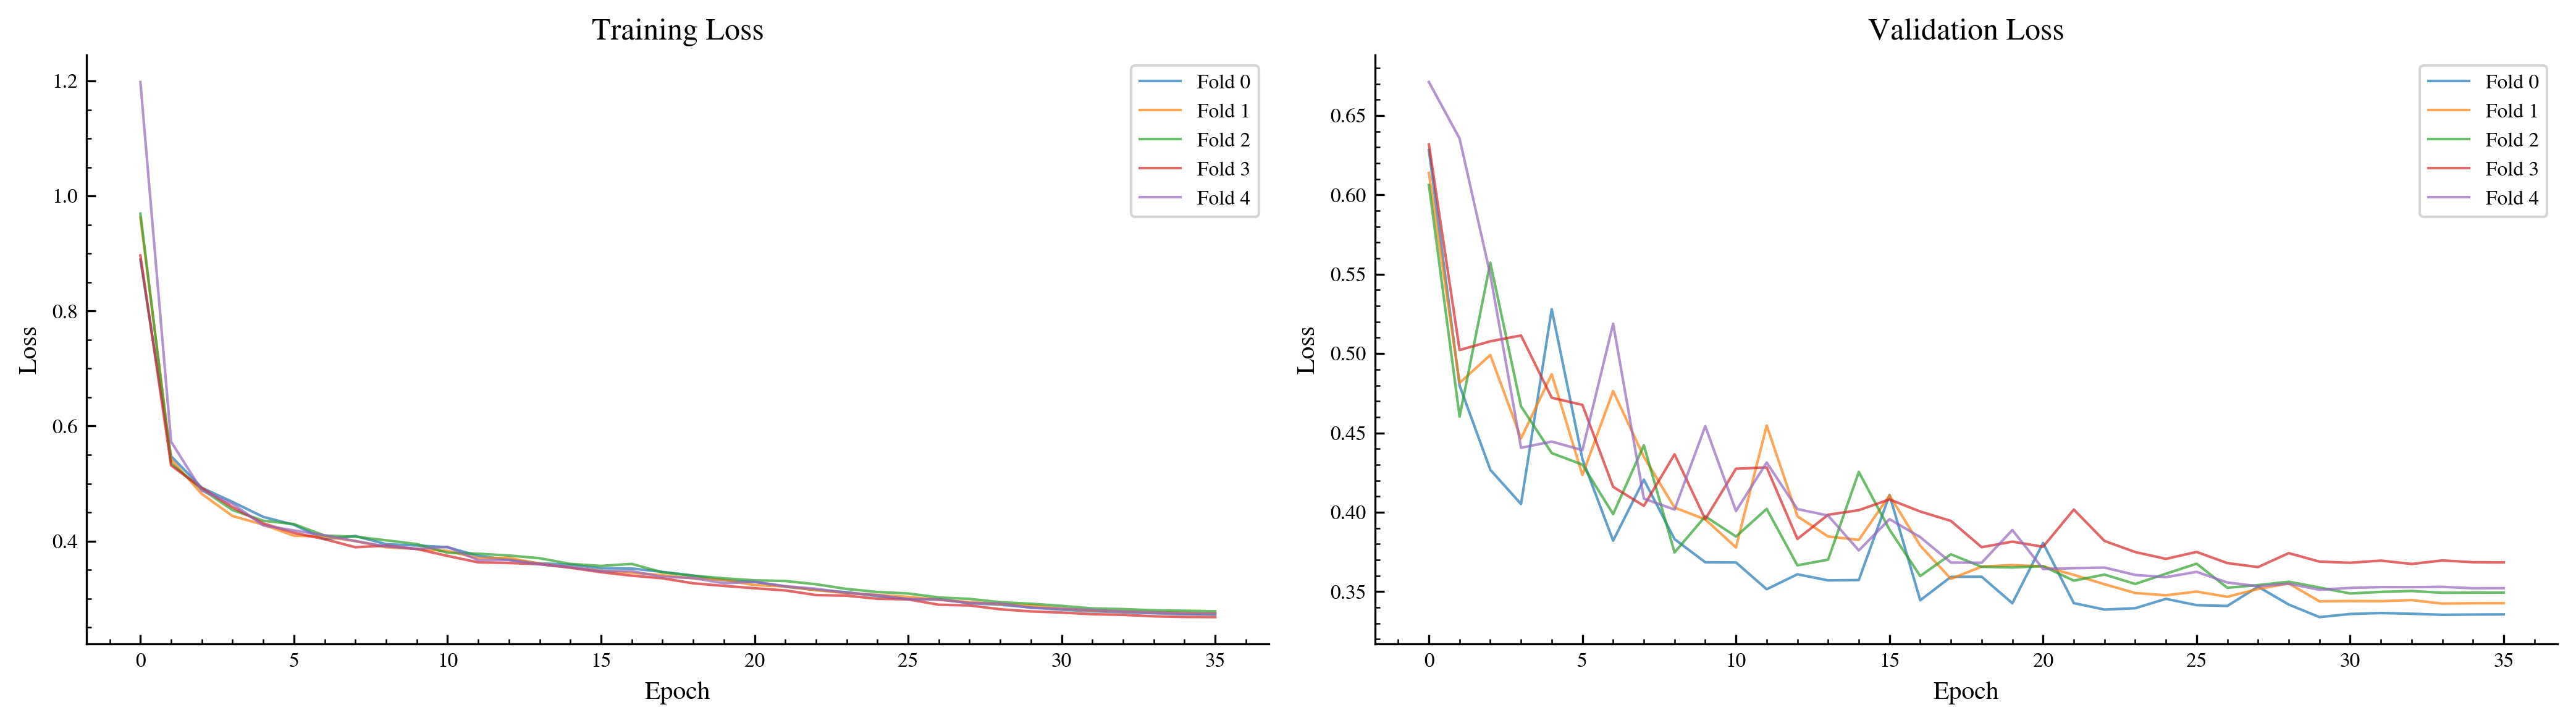

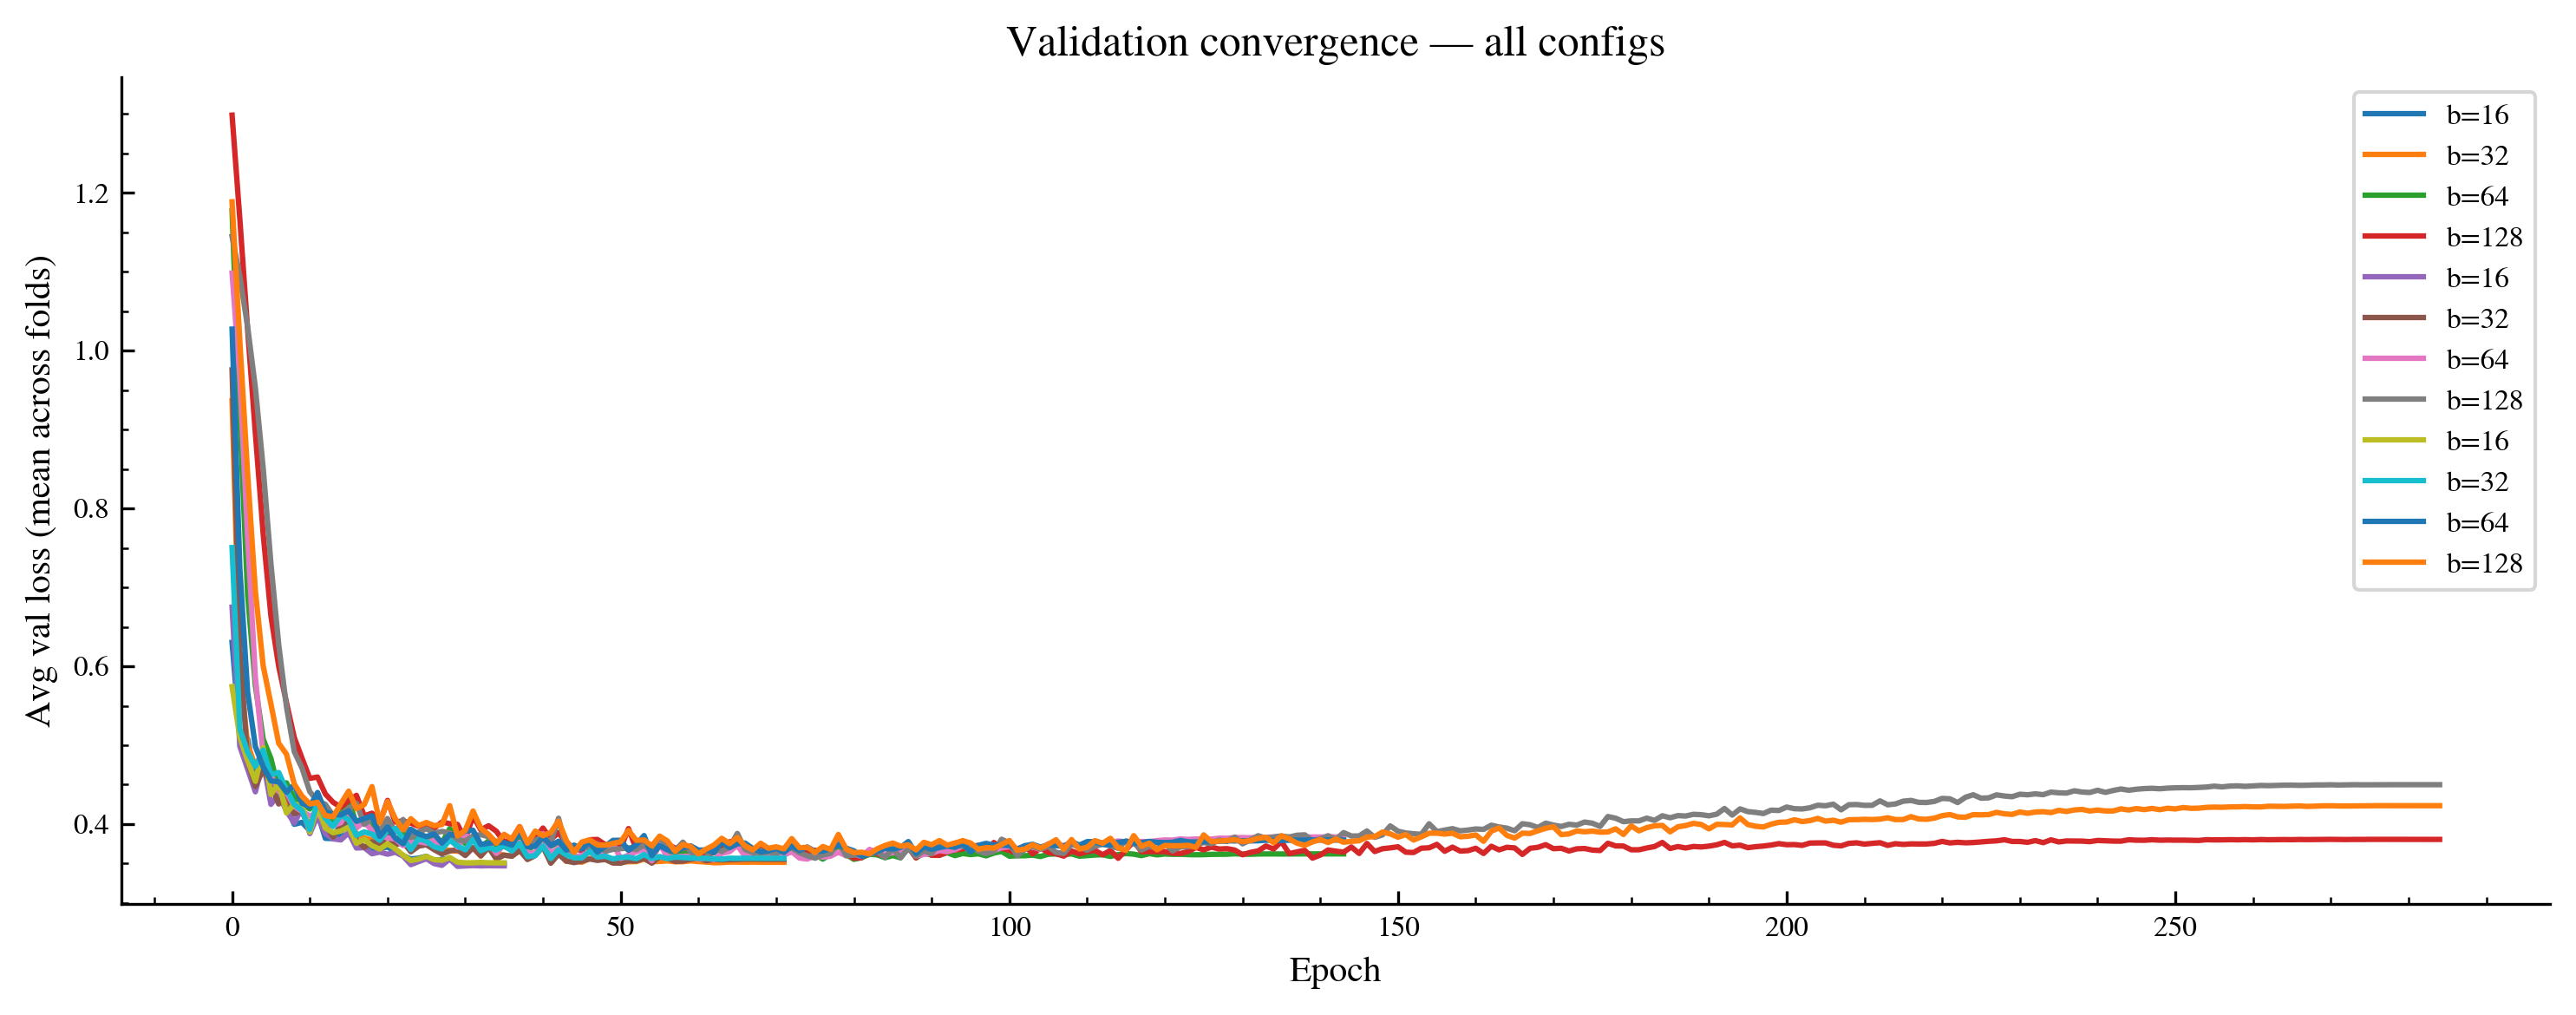

In [ ]:
comparison = pd.DataFrame([
    dict(config          = name,
         hidden          = str(cfg['hidden_features']),
         batch_size      = cfg['batch_size'],
         mean_test_ll    = sweep_results[name]['mean_test_ll'],
         ll_std          = float(np.std(sweep_results[name]['test_lls'])),
         median_residual = float(sweep_results[name]['results_df']['residual_dex'].median()),
         median_precision= float((sweep_results[name]['results_df']['p84'] - sweep_results[name]['results_df']['p16']).median()))
    for cfg in CONFIGS
    for name in [cfg['name']]
]).sort_values('mean_test_ll', ascending=False).reset_index(drop=True)

comparison.index += 1
print(comparison.to_string())
print()

best_name = comparison.iloc[0]['config']
print(f'Best config: {best_name}  (mean test LL = {comparison.iloc[0]["mean_test_ll"]:.6f})')

best = sweep_results[best_name]
training_report(best['train_curves'], best['val_curves'])

# Average val loss per epoch across folds, for every config
fig, ax = plt.subplots(figsize=(10, 4))
for cfg in CONFIGS:
    name = cfg['name']
    vc   = sweep_results[name]['val_curves']   # list of fold curves (may differ in length)
    min_len = min(len(c) for c in vc)
    avg_val = np.mean([c[:min_len] for c in vc], axis=0)
    ax.plot(avg_val, label=f"b={cfg['batch_size']}", lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Avg val loss (mean across folds)')
ax.set_title('Validation convergence — all configs')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Residual diagnostics

/Users/alanxia/Documents/GitHub/cf_xmatch/training/notebooks/../../training/plots.py:287: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.scatter(xvals, resid, **_kw_scat)


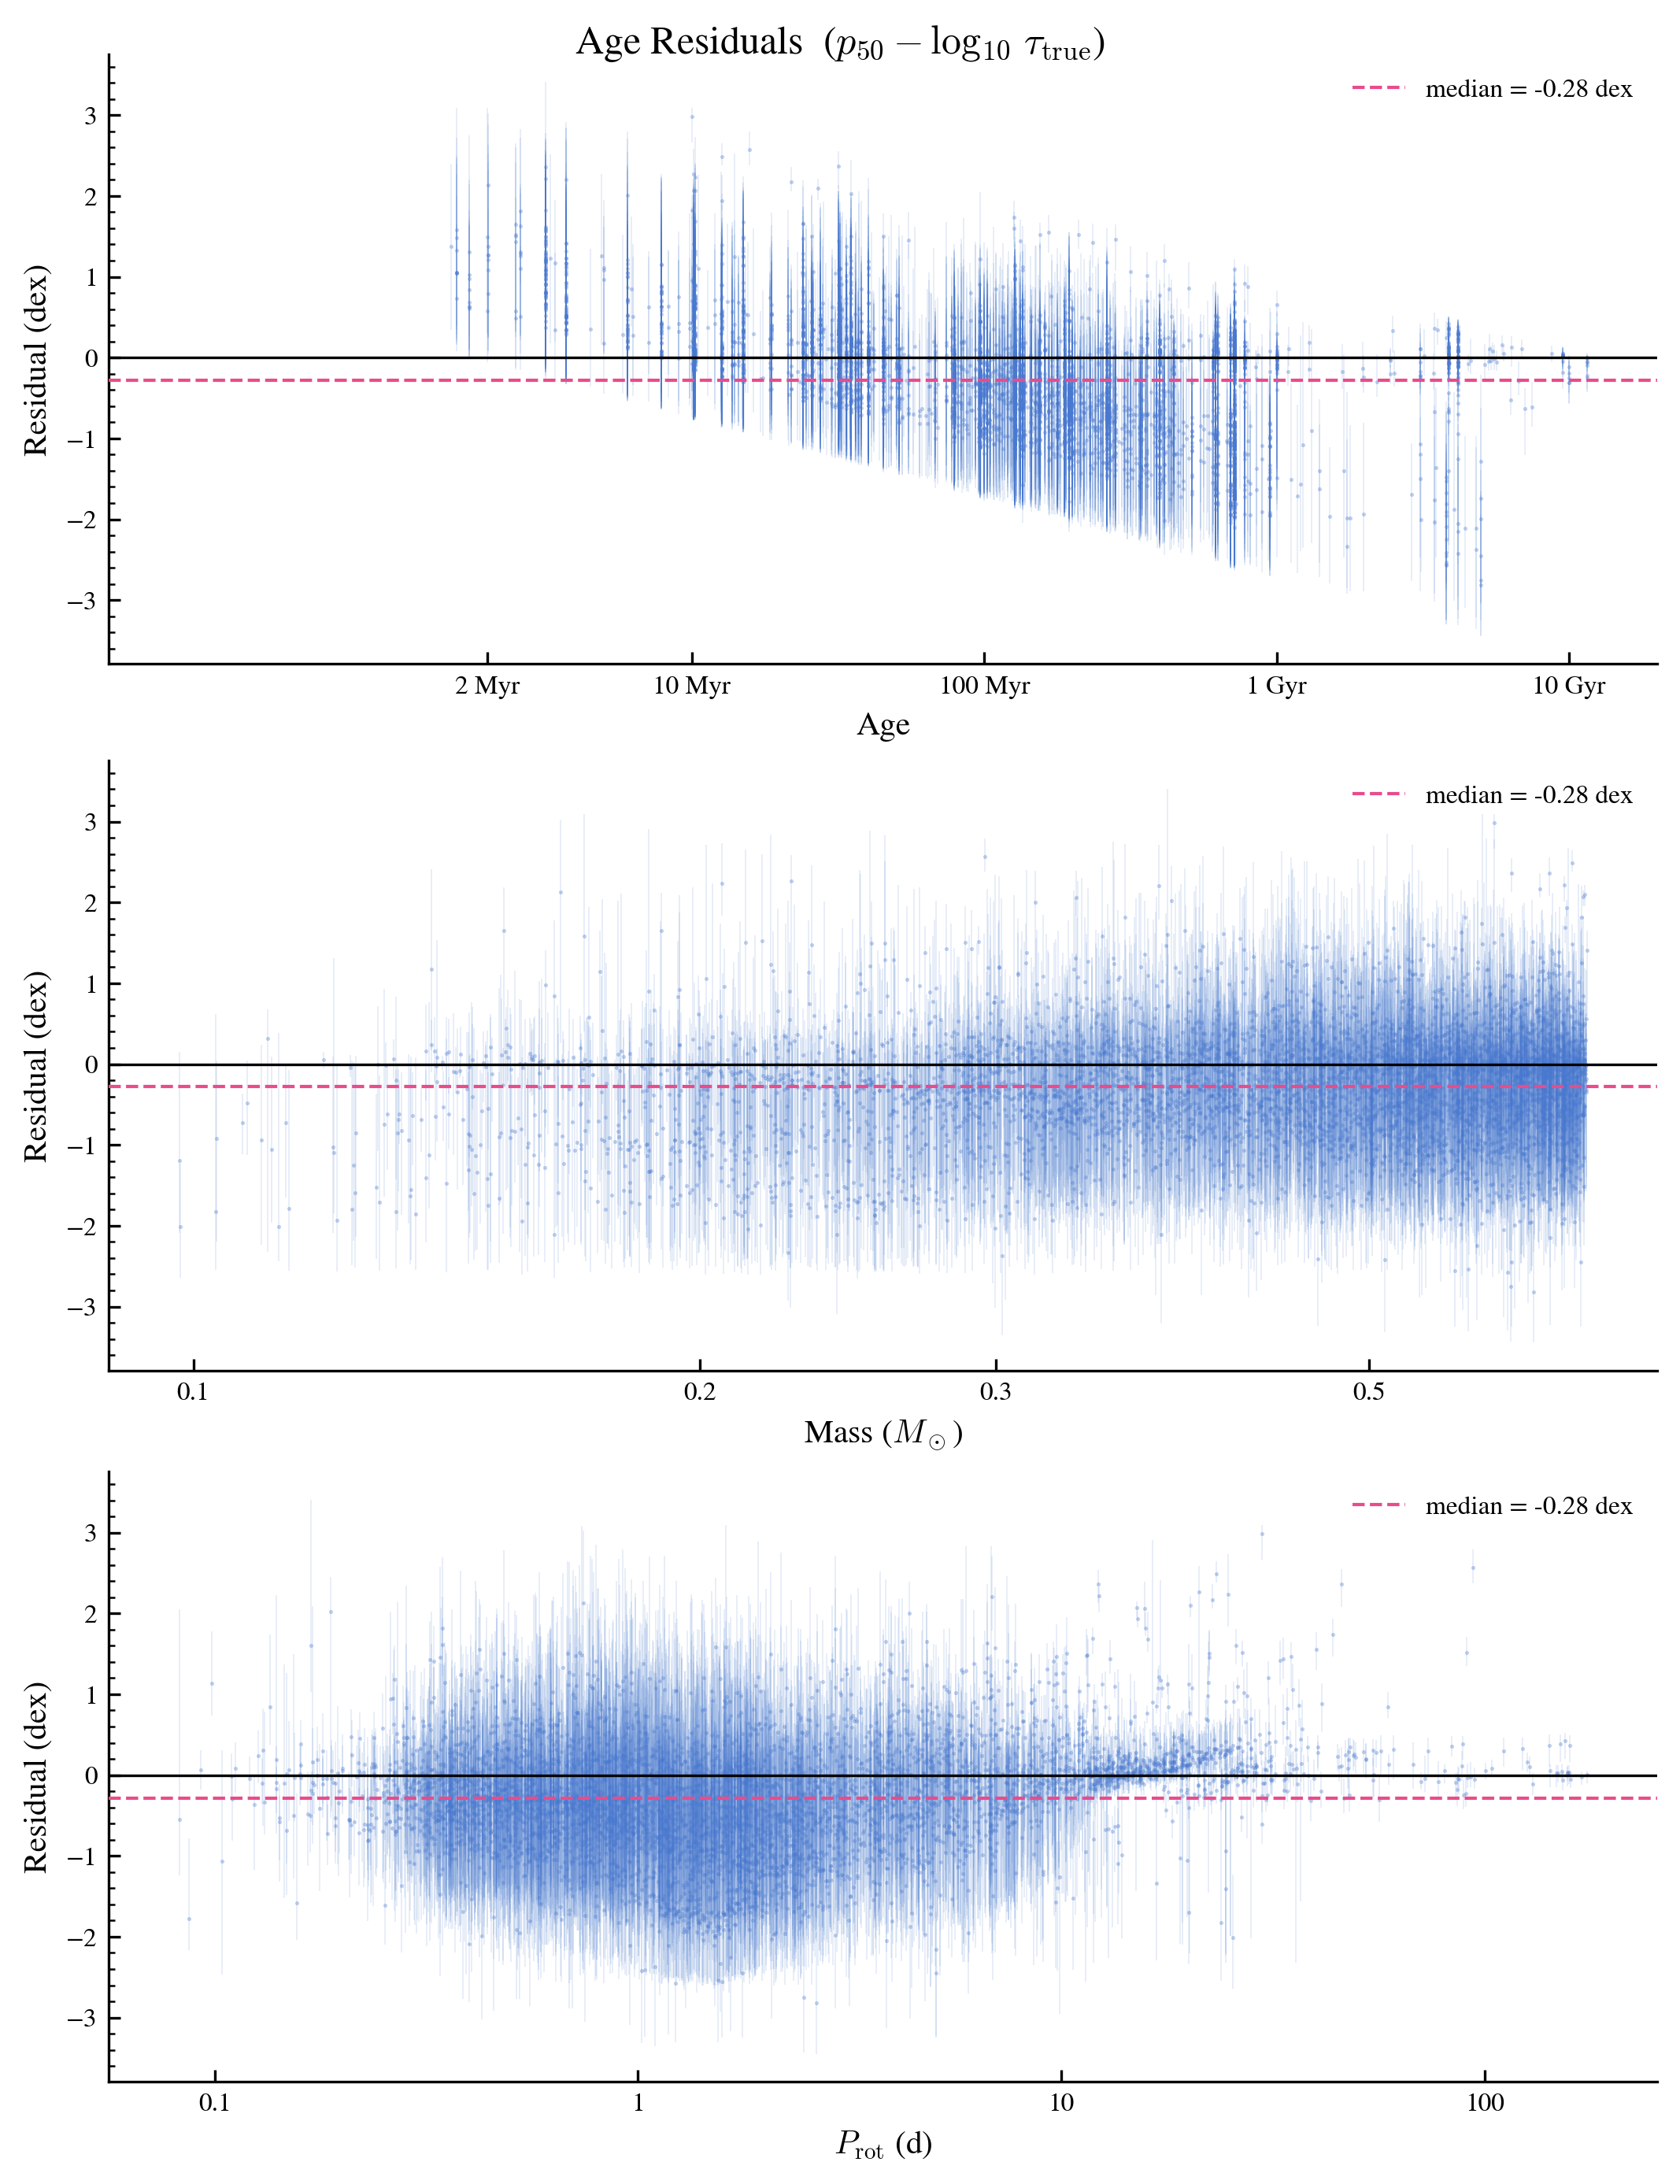

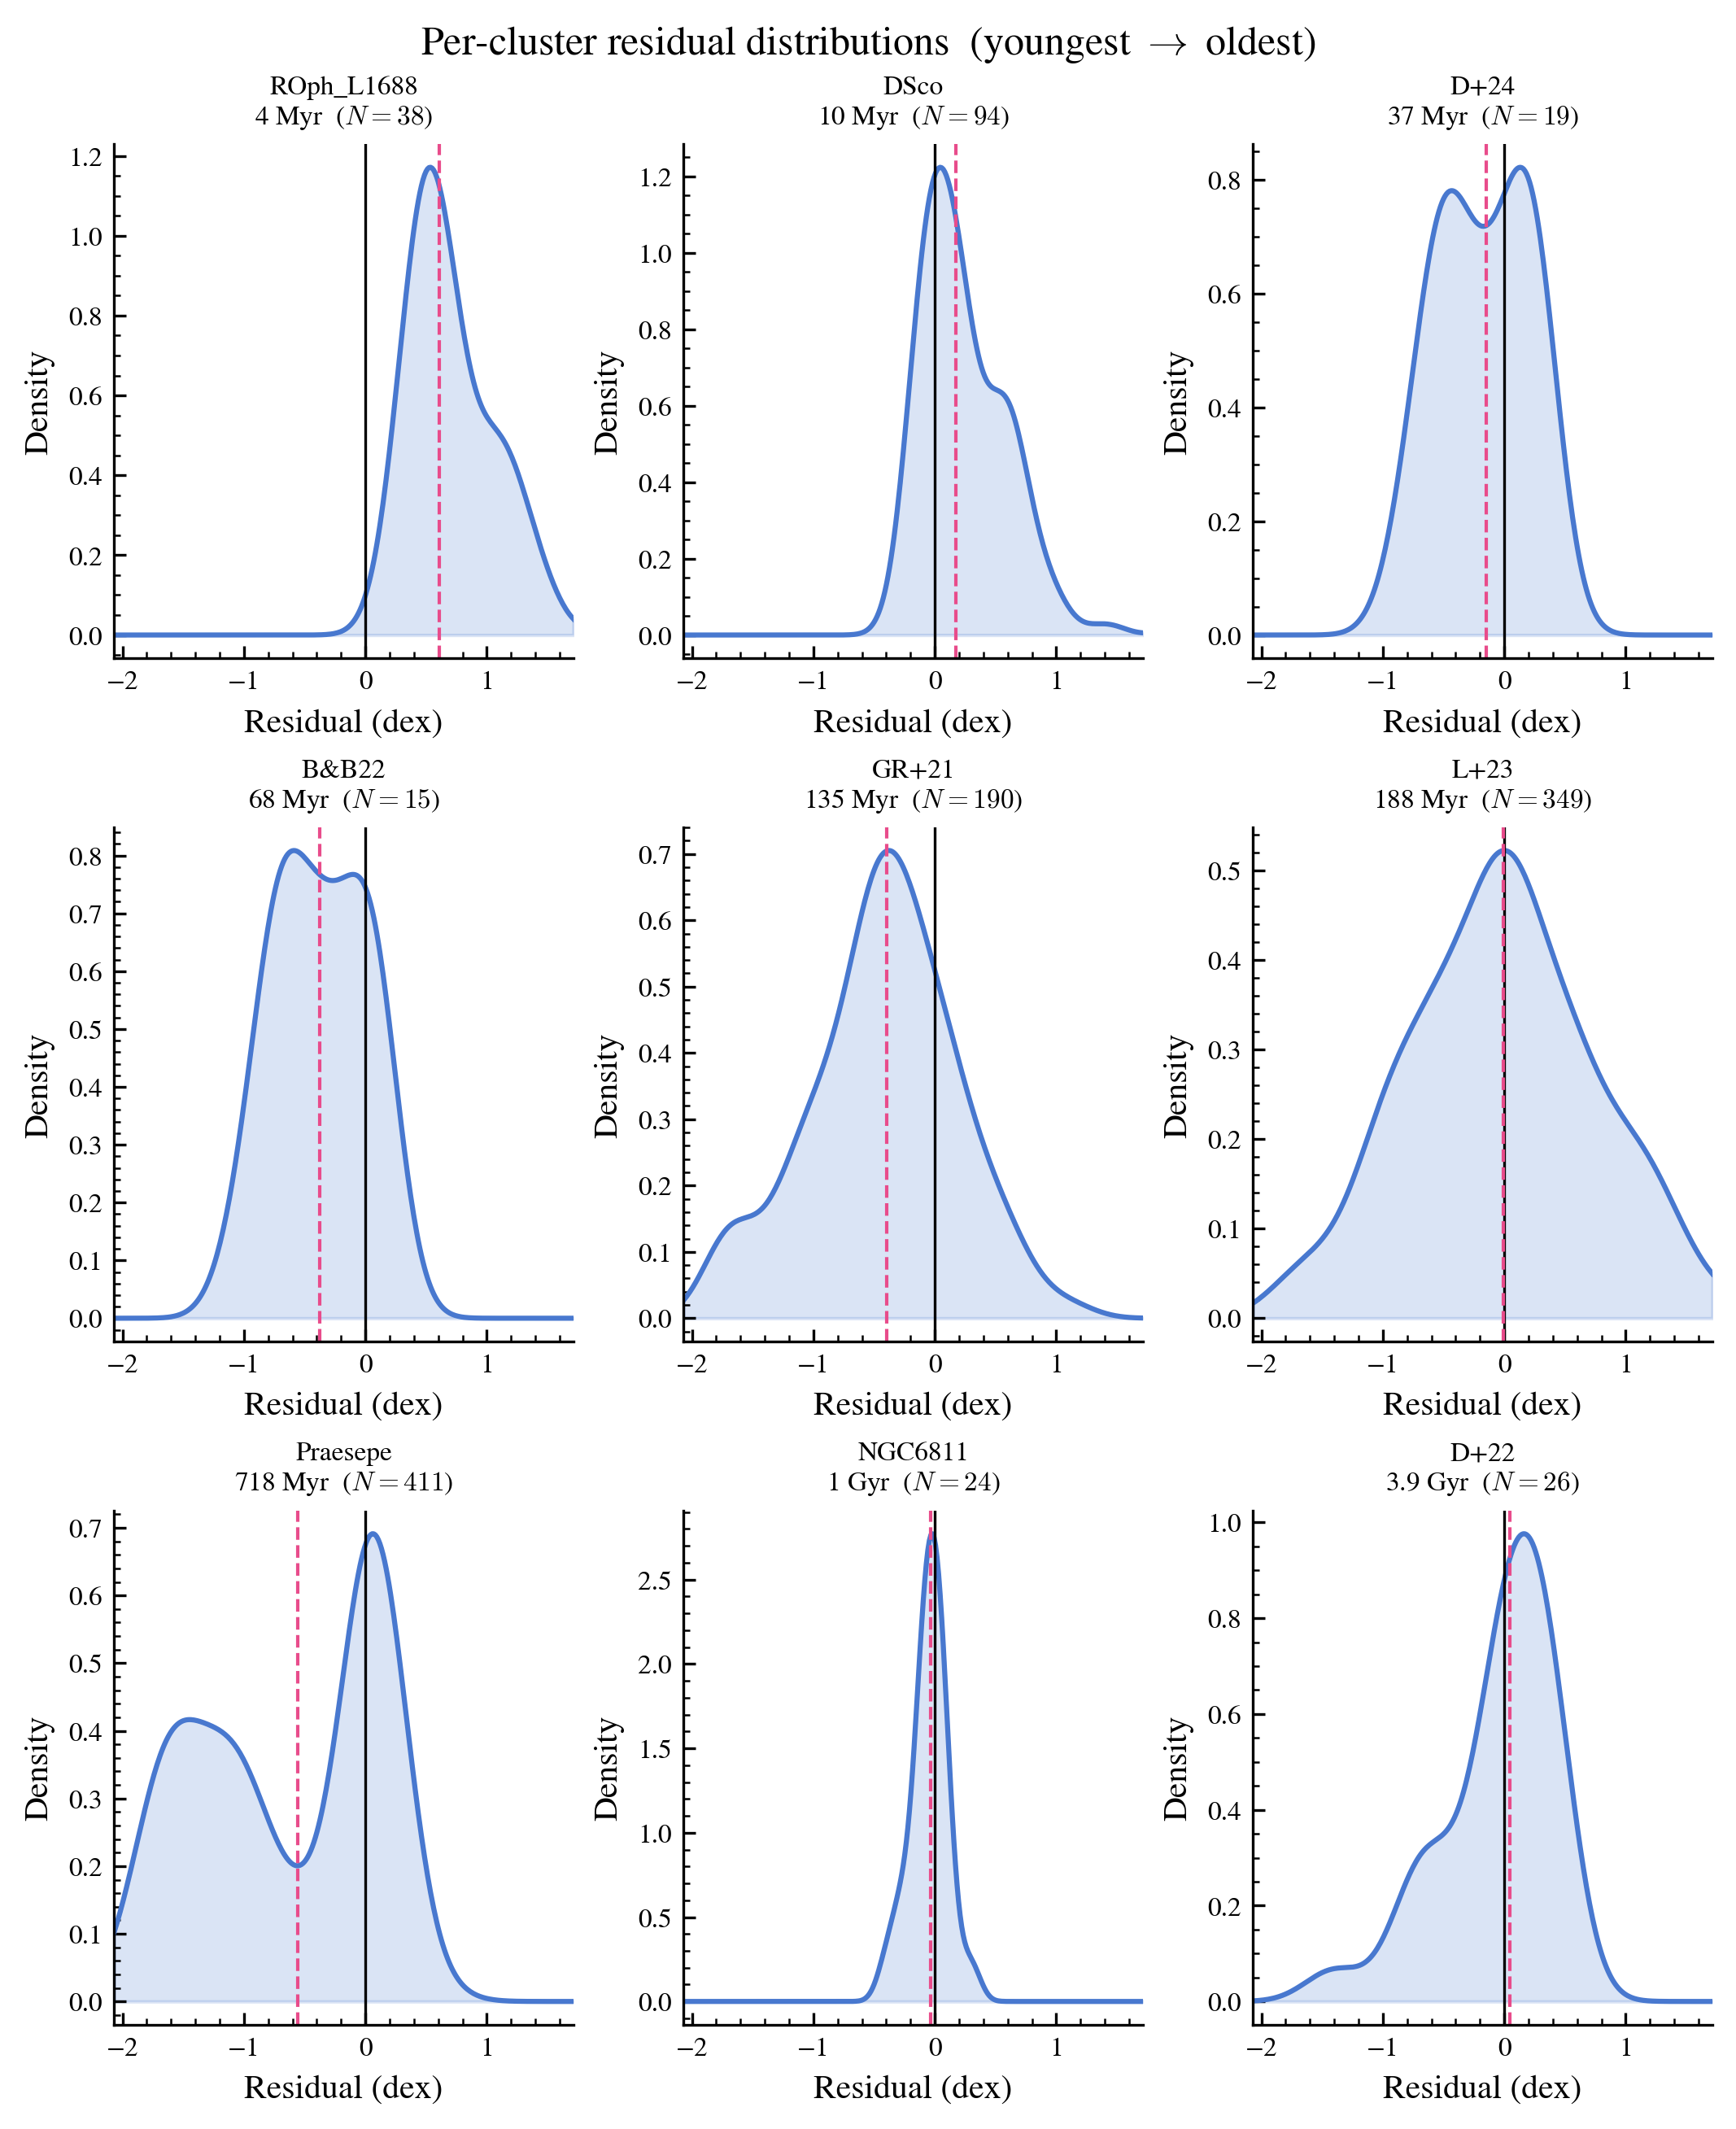

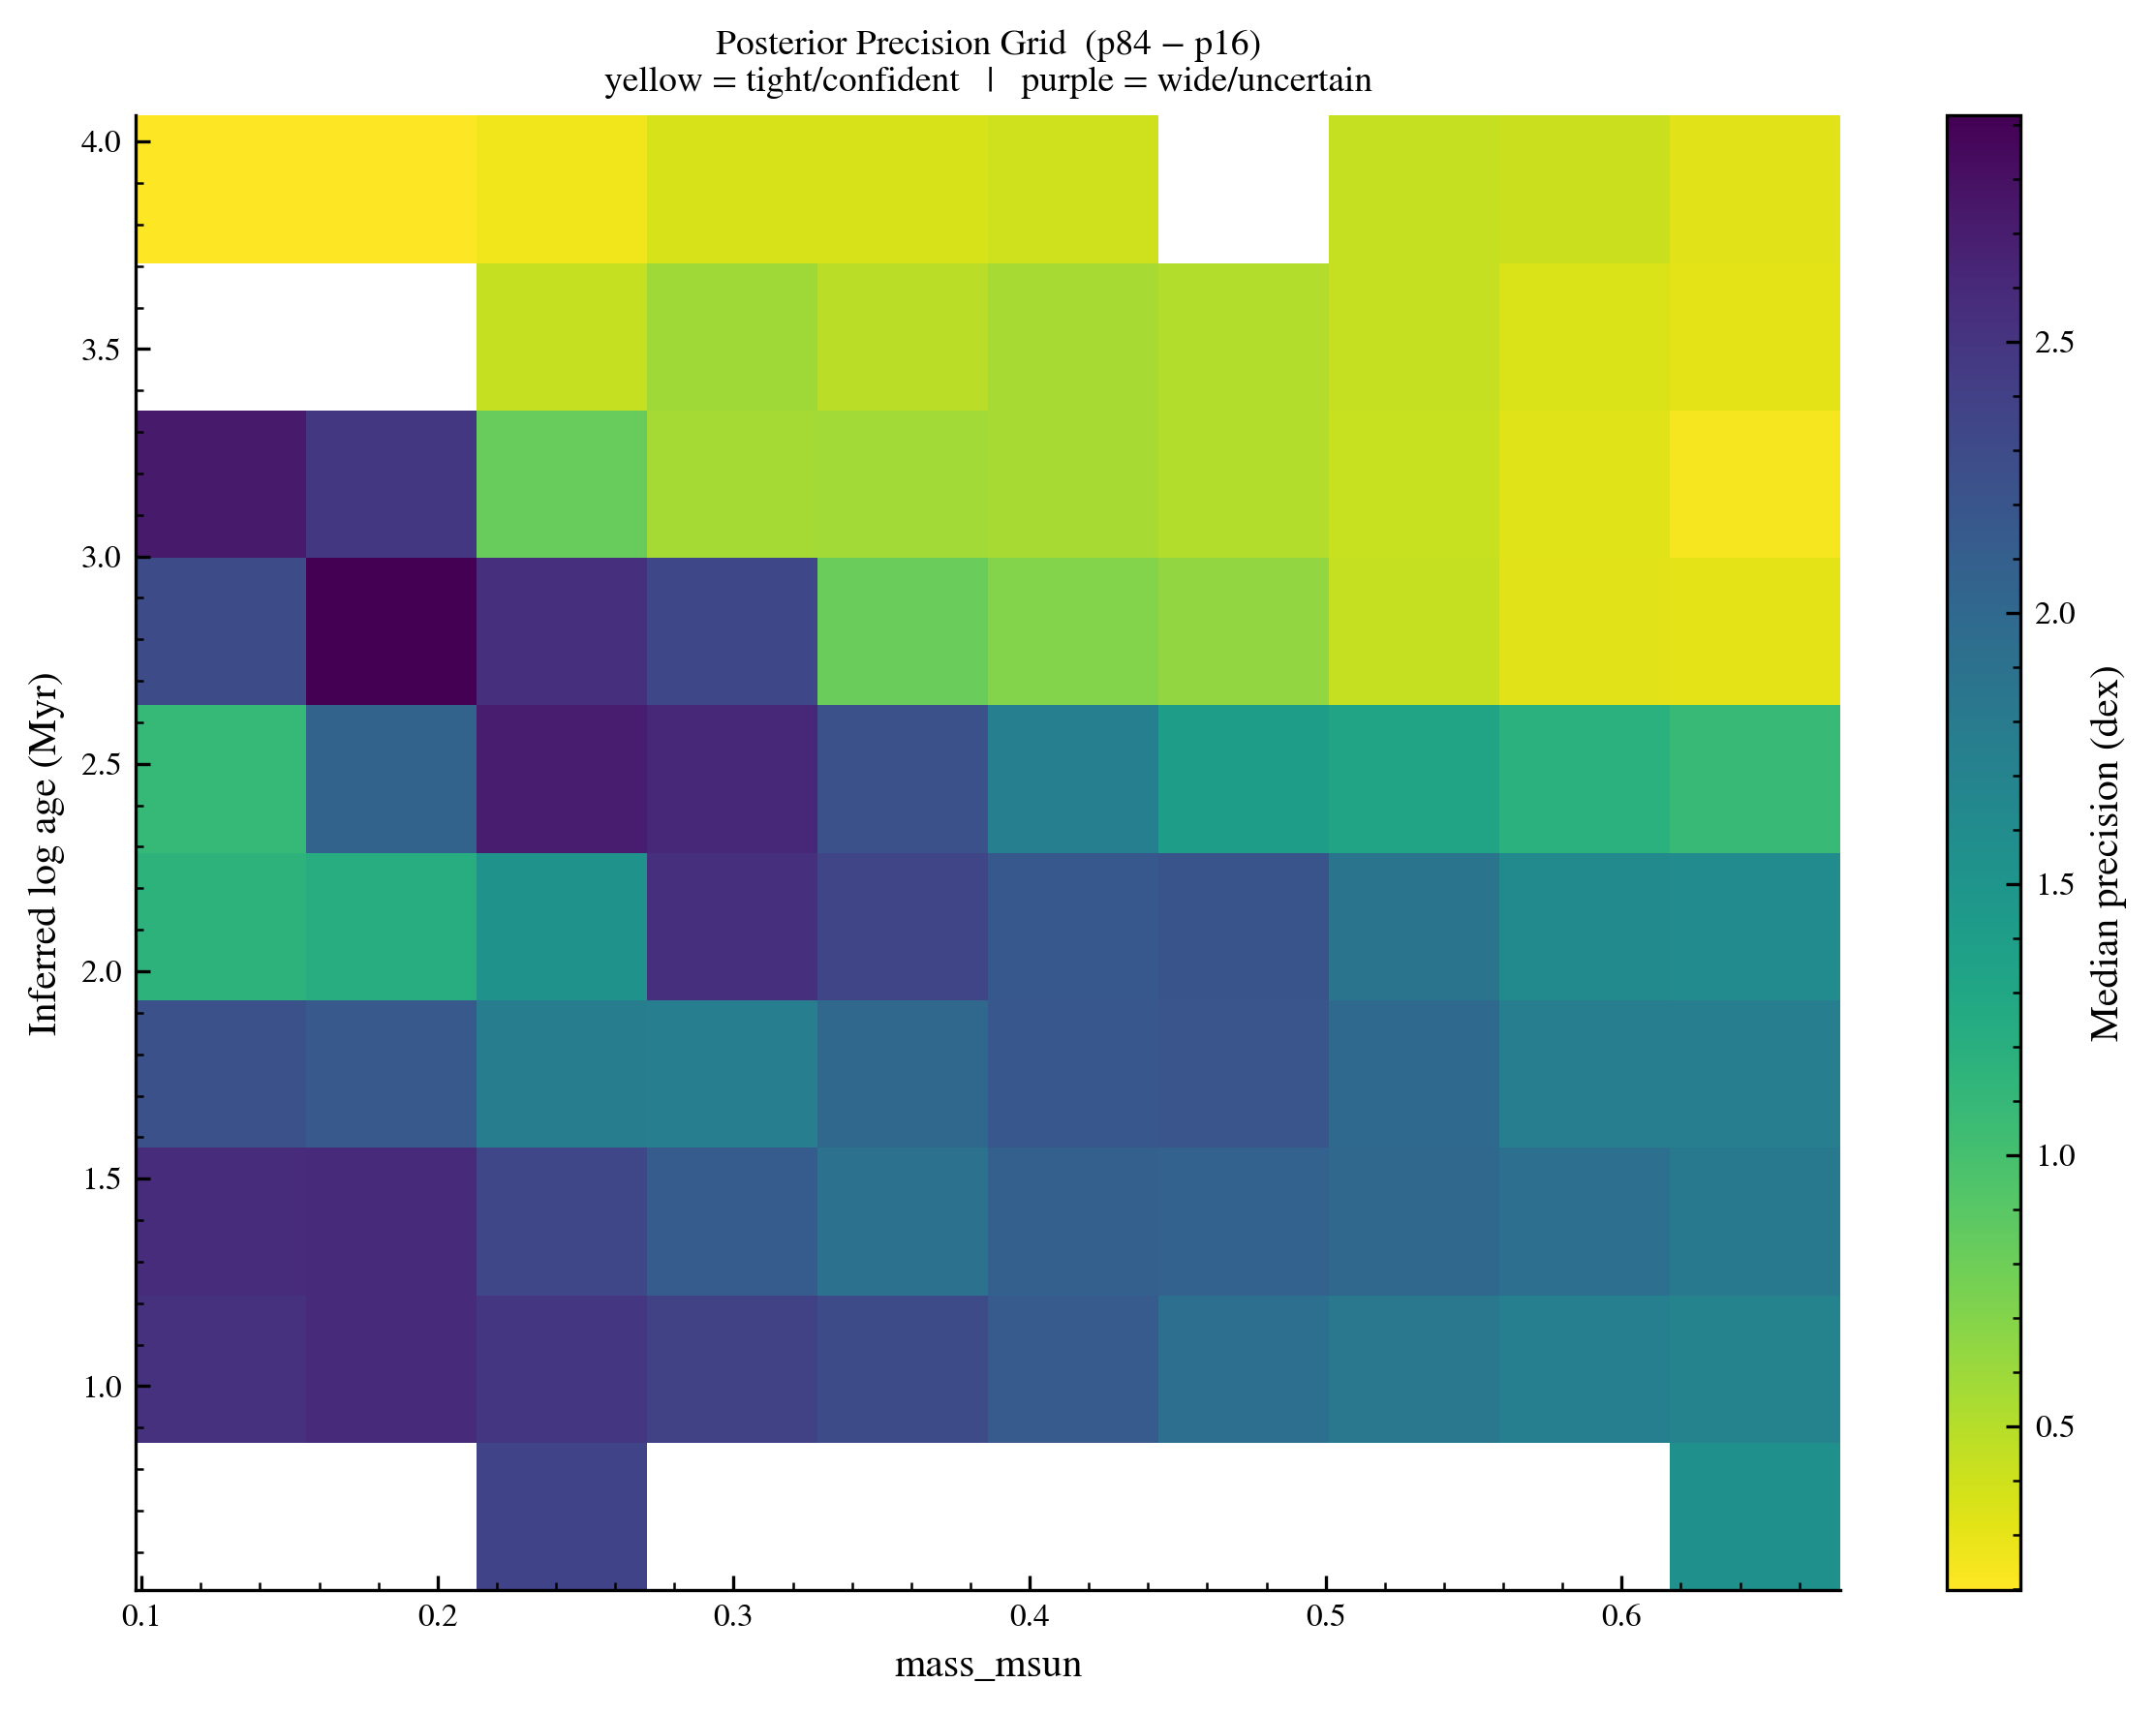

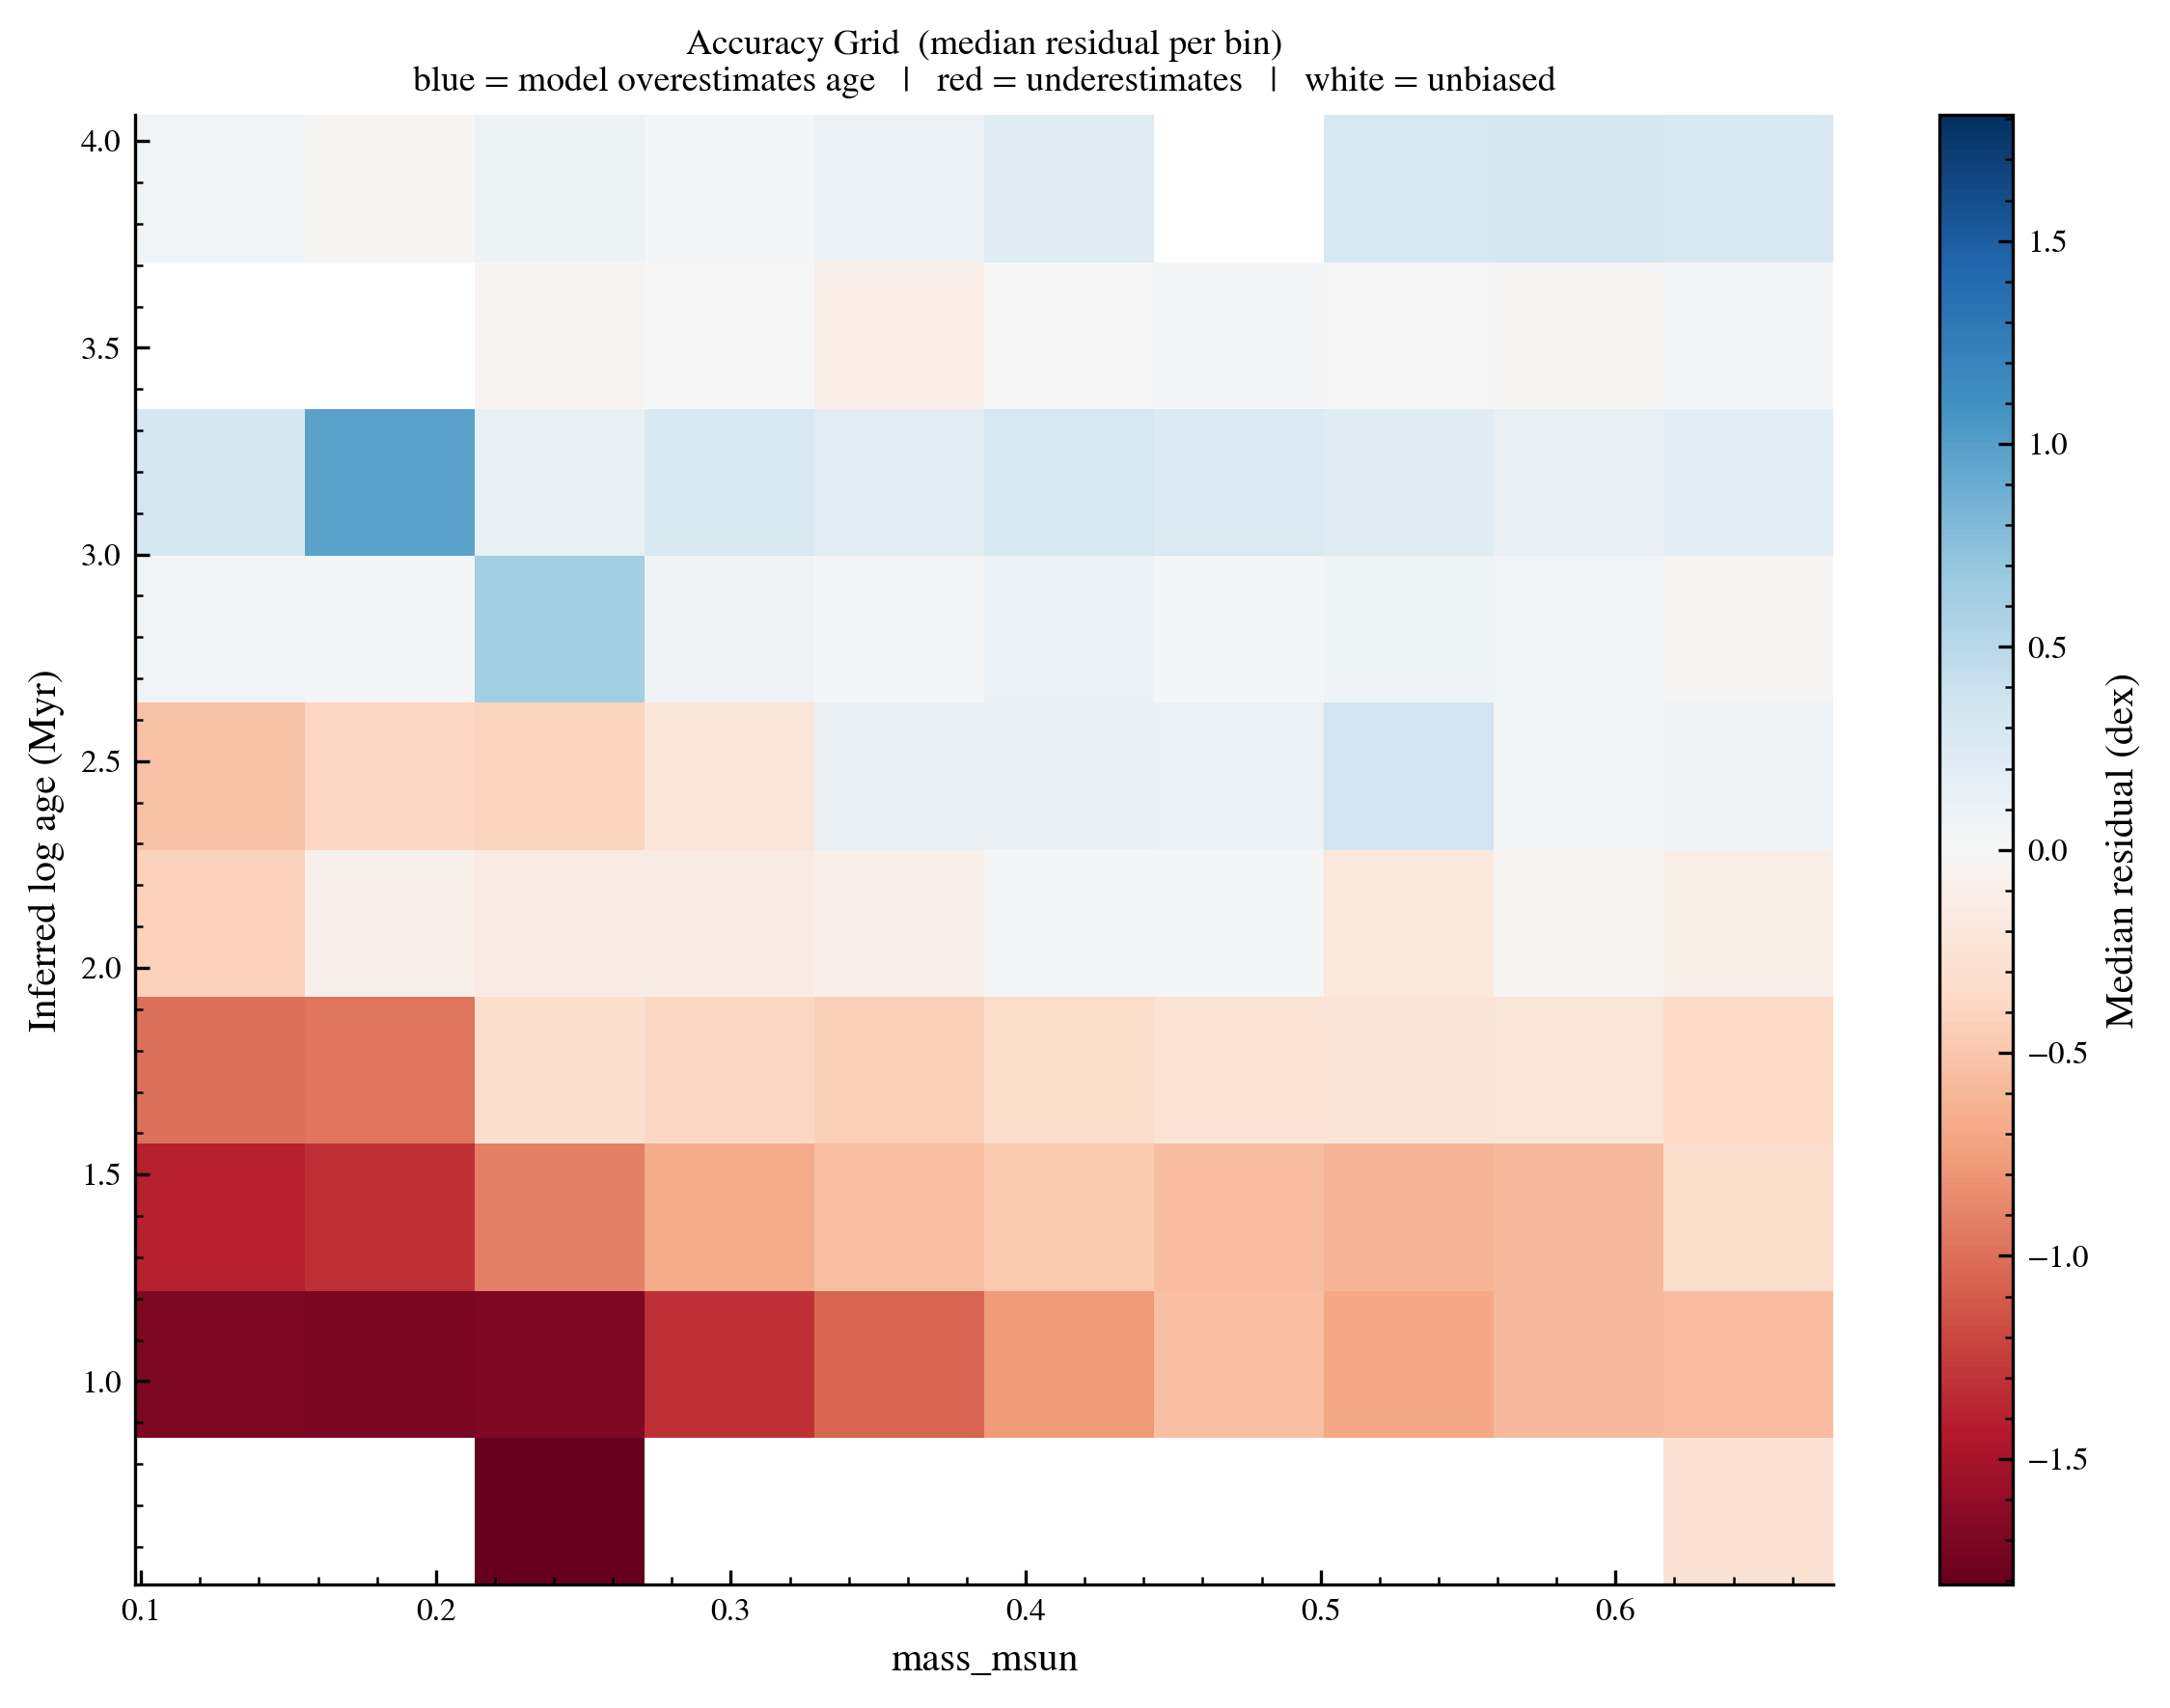

In [ ]:
import importlib, training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import kfold_report

kfold_report(best['results_df'])

## 6. Sample posteriors by age range

Posteriors shape: (5515, 1000)


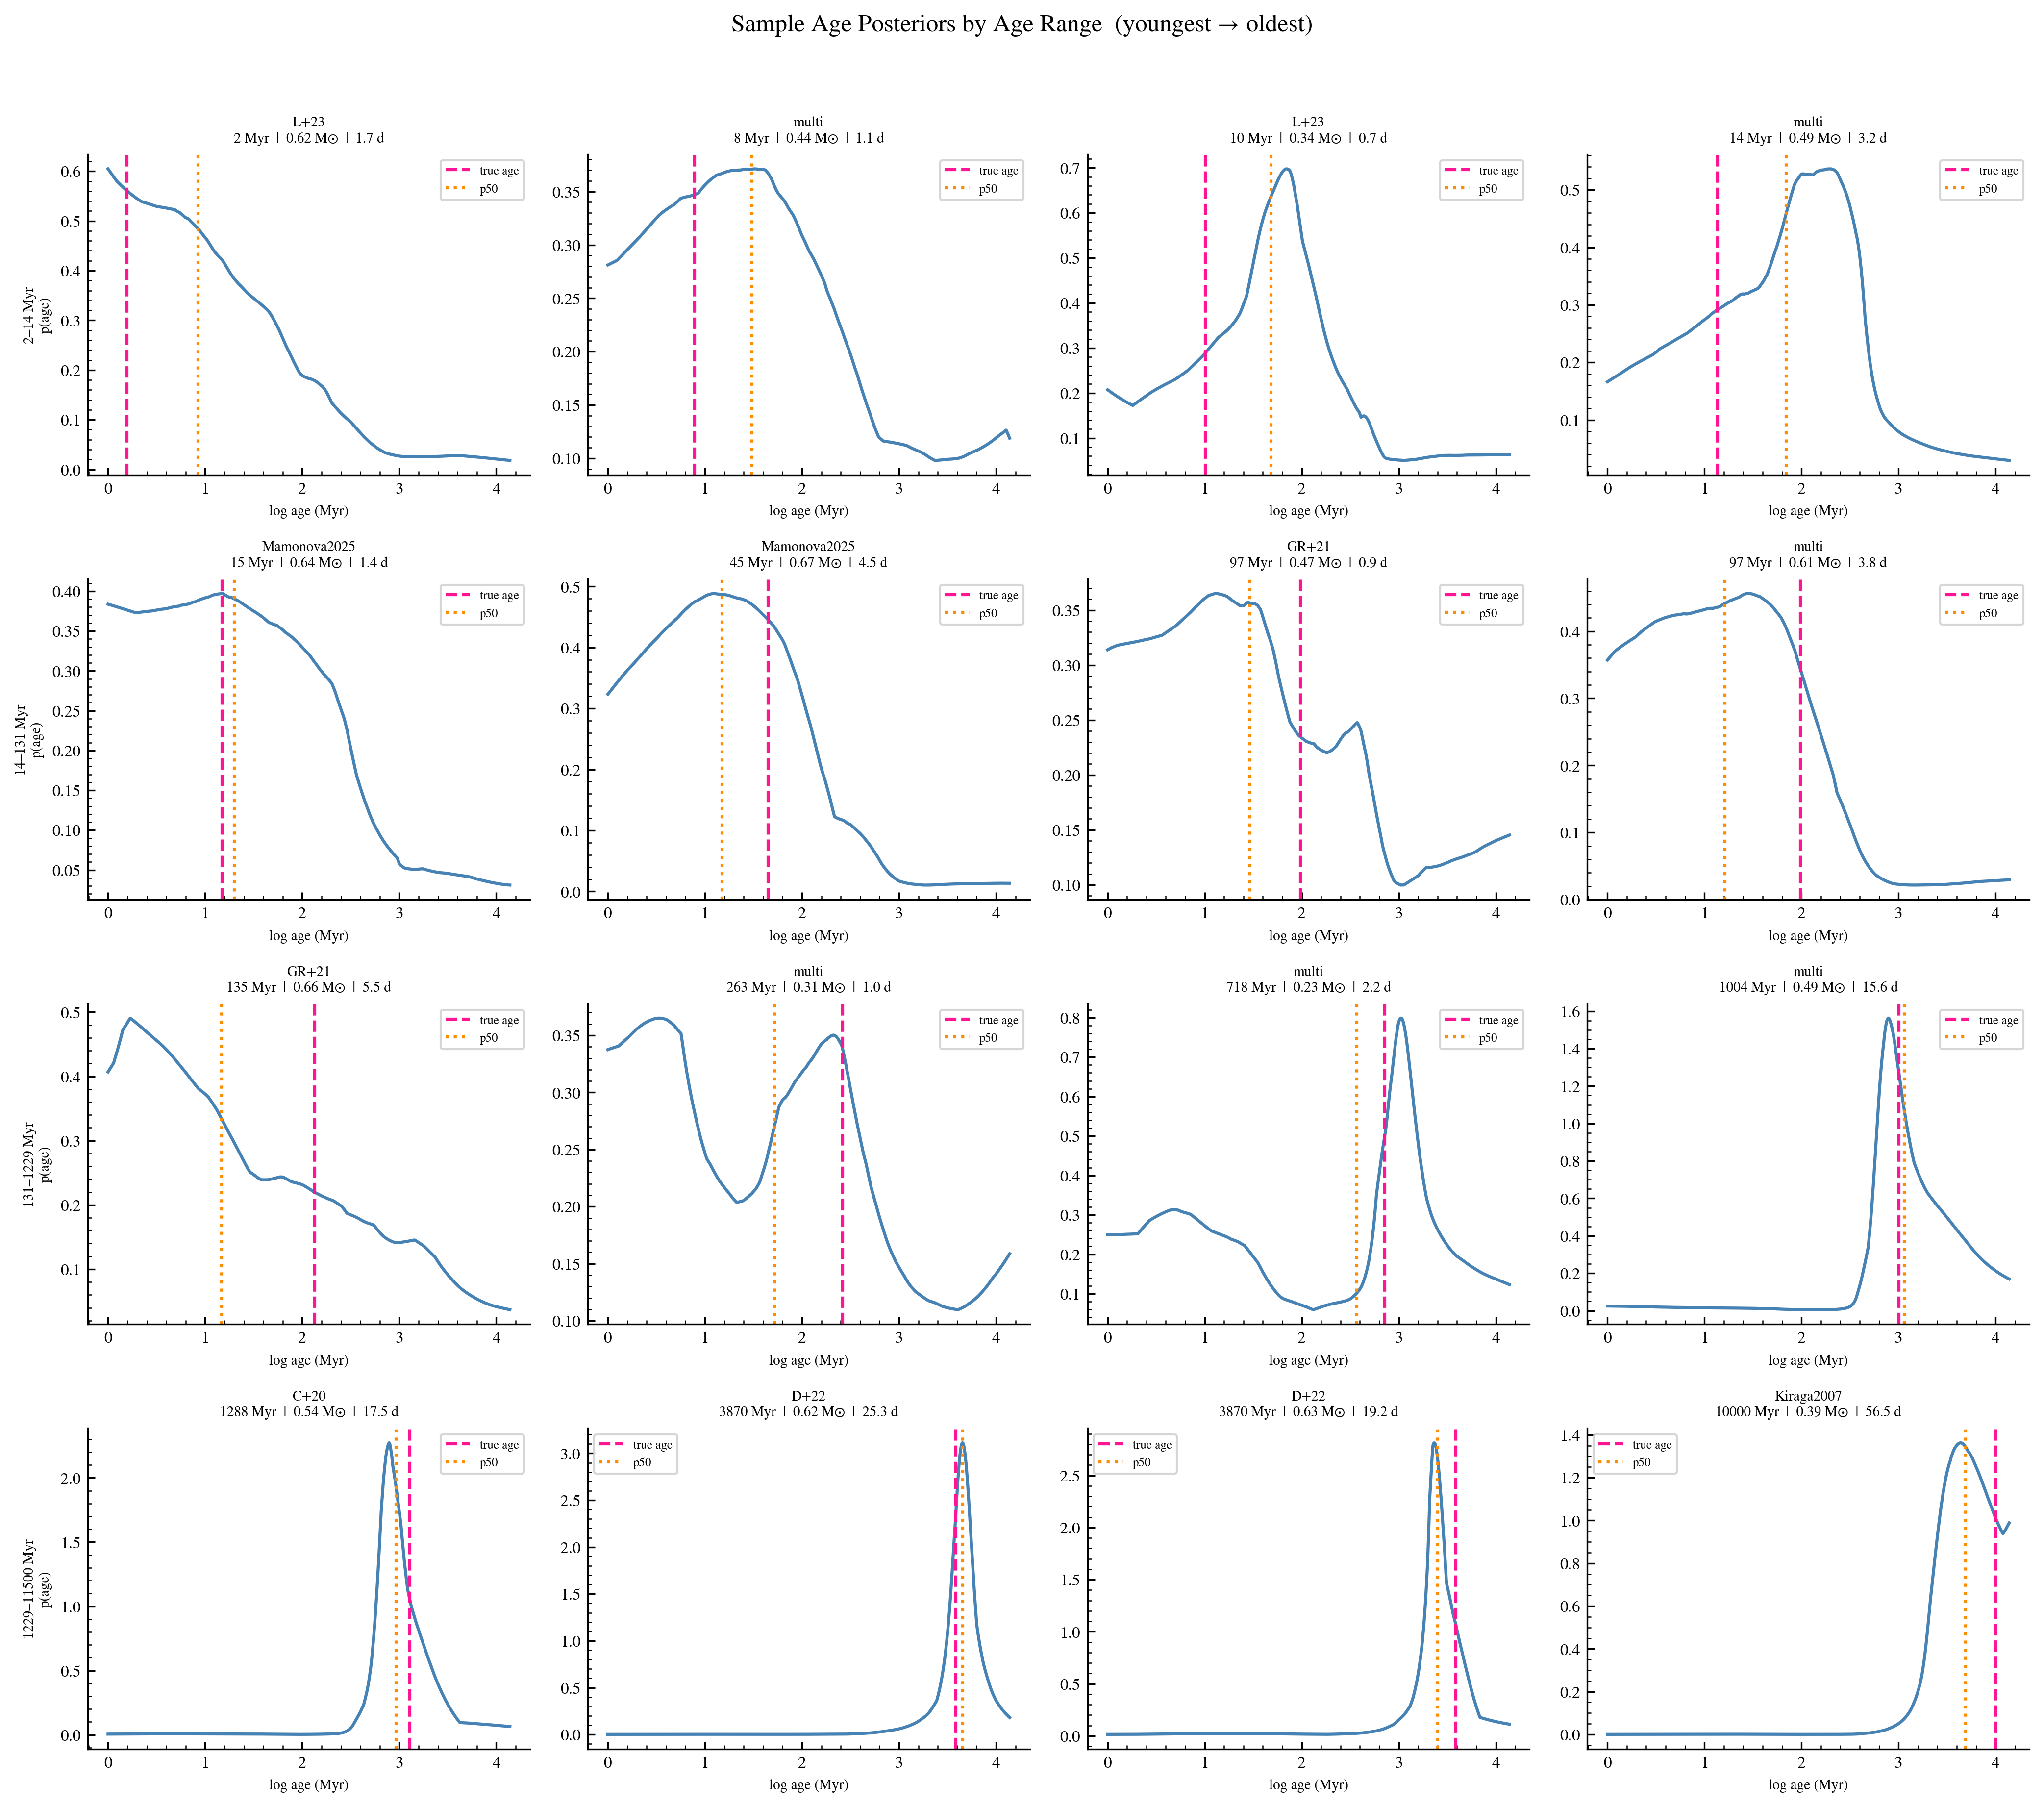

In [ ]:
print('Posteriors shape:', best['posteriors'].shape)
plot_posteriors_by_age(best['posteriors'], LOGA_GRID, best['results_df'], n_rows=4, n_cols=4)

## 6b. Posteriors near the fully convective boundary (0.3–0.4 M☉)

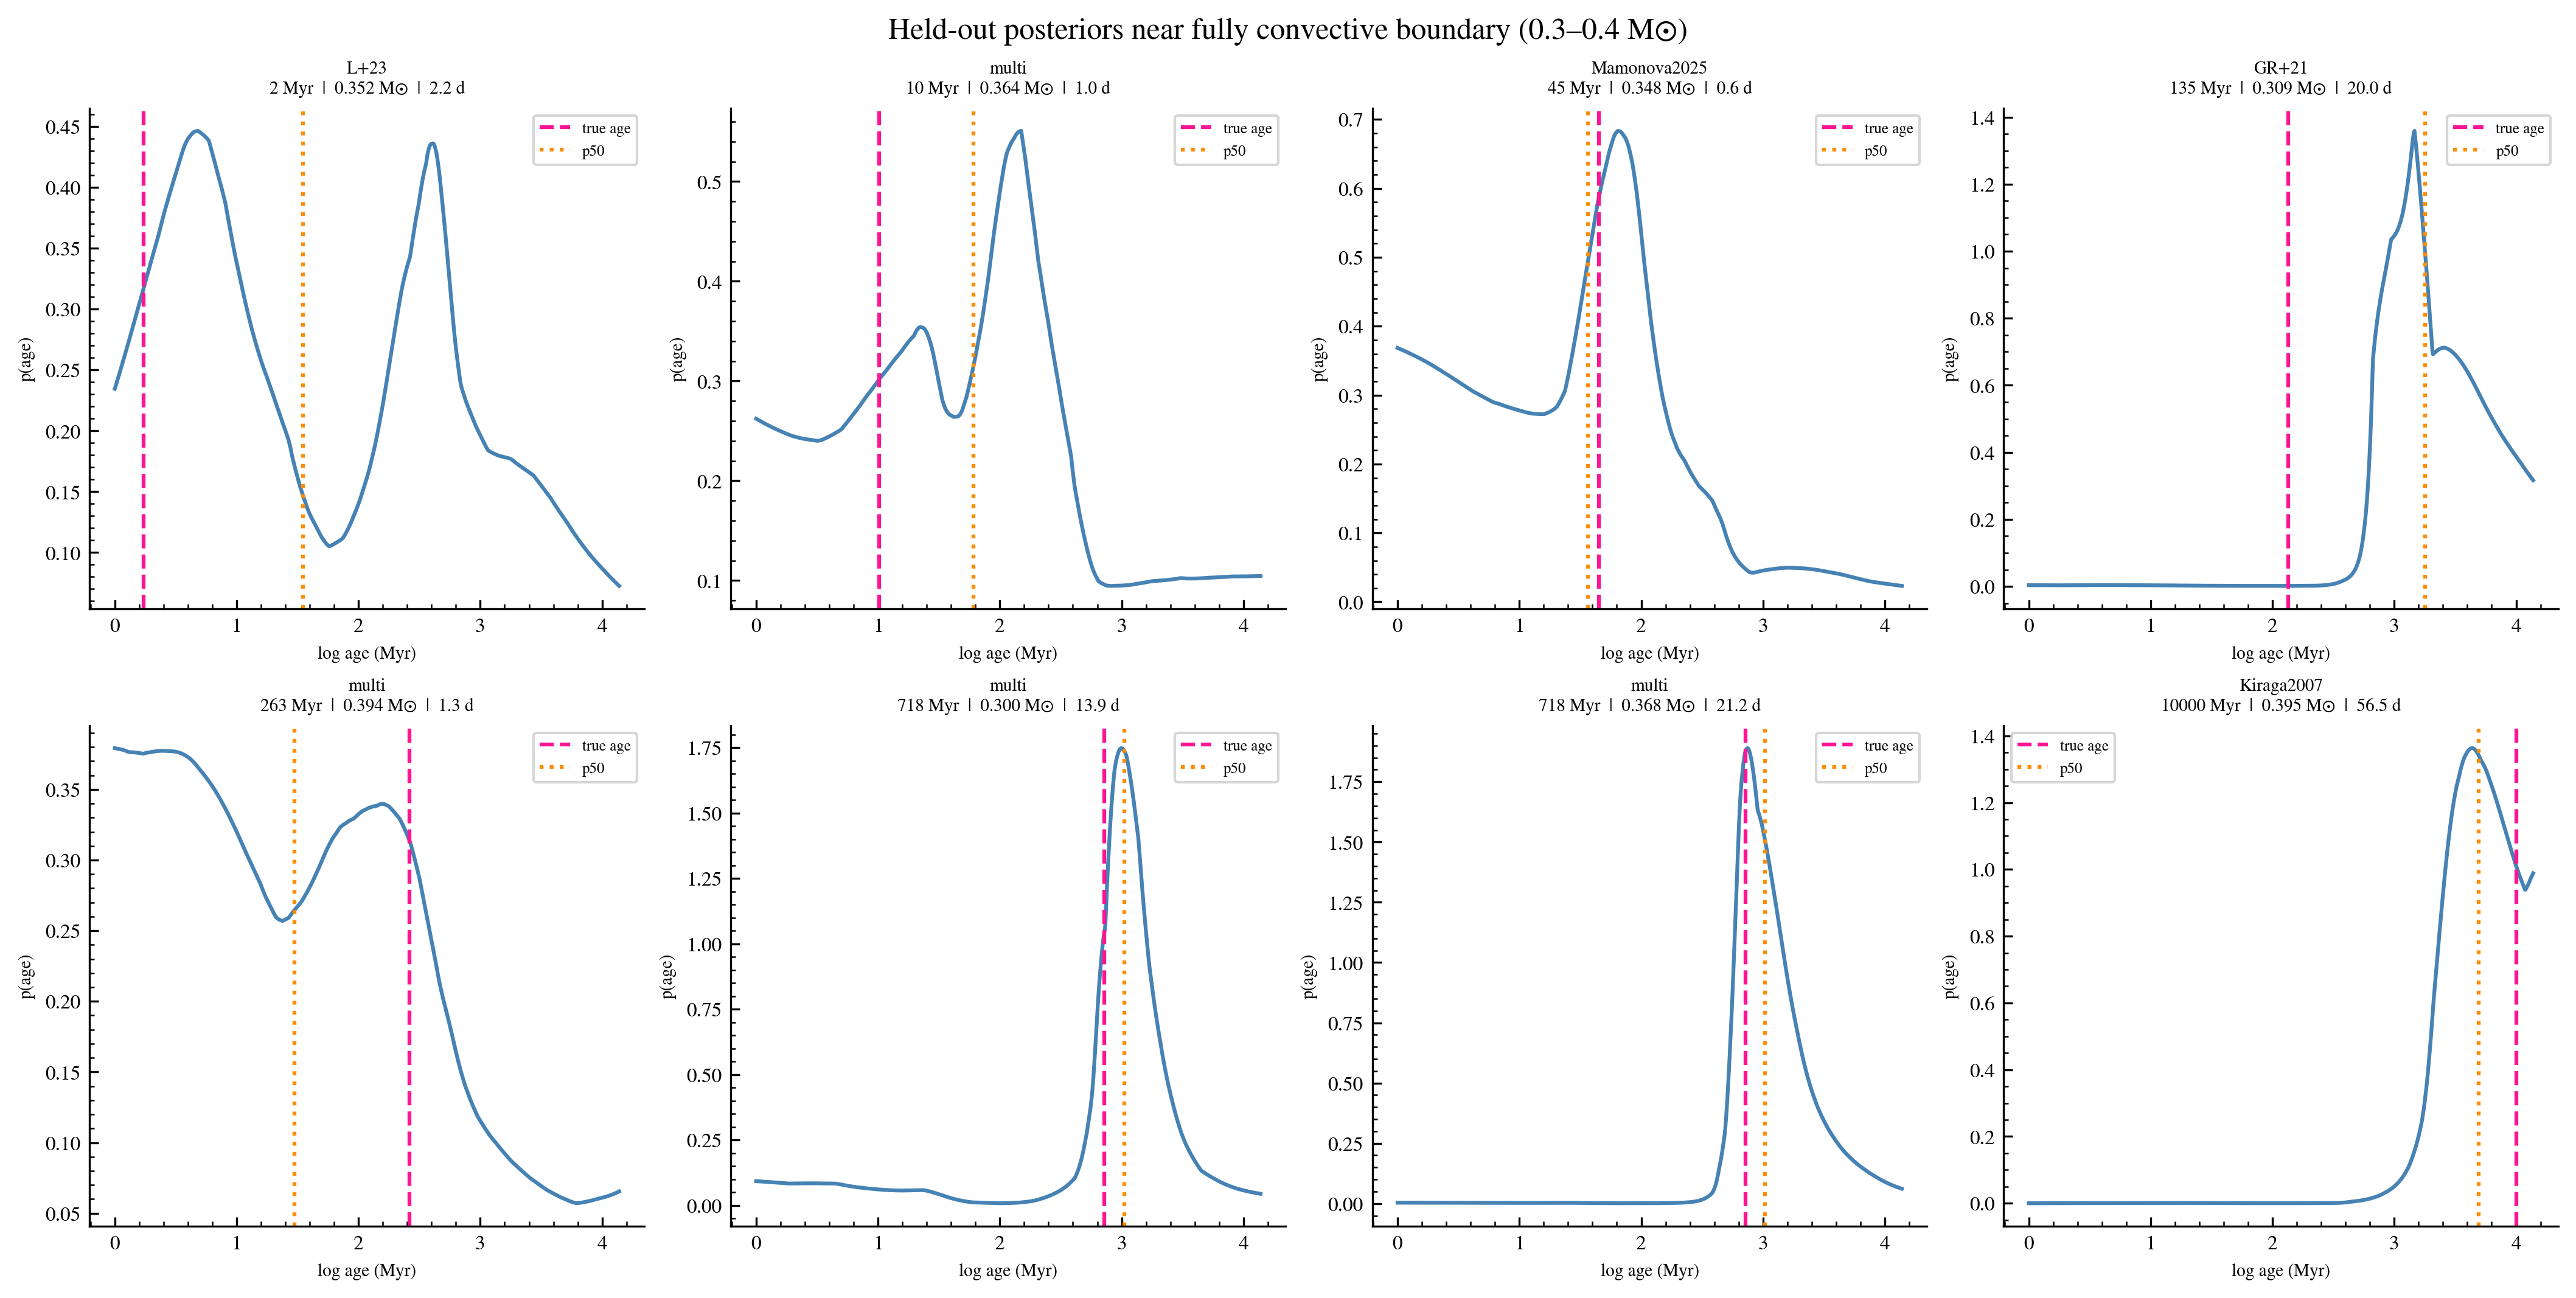

In [ ]:
_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}

_results_df      = best['results_df']
_posteriors      = best['posteriors']

fc_mask = (_results_df['mass_msun'] >= 0.3) & (_results_df['mass_msun'] <= 0.4)
fc_df   = _results_df[fc_mask].copy().reset_index(drop=True)
fc_pos  = np.where(fc_mask)[0]

is_cluster = ~fc_df['source_paper'].isin(_field)
pool_idx   = np.where(is_cluster)[0] if is_cluster.sum() >= 8 else np.arange(len(fc_df))
age_order  = pool_idx[np.argsort(fc_df.iloc[pool_idx]['log_age_myr'].values)]
pick       = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7), layout='constrained')
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = fc_df.iloc[i]
    post_idx = fc_pos[i]
    ax.plot(LOGA_GRID, _posteriors[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink',  lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'],         color='darkorange', lw=1.5, ls=':',  label='p50')
    ax.set_title(
        f"{row['source_paper']}\n"
        f"{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d",
        fontsize=7,
    )
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
fig.suptitle('Held-out posteriors near fully convective boundary (0.3–0.4 M☉)')
plt.show()

## 7. $P(P_\mathrm{rot}\,|\,\mathrm{age,\,mass})$ heatmap per cluster

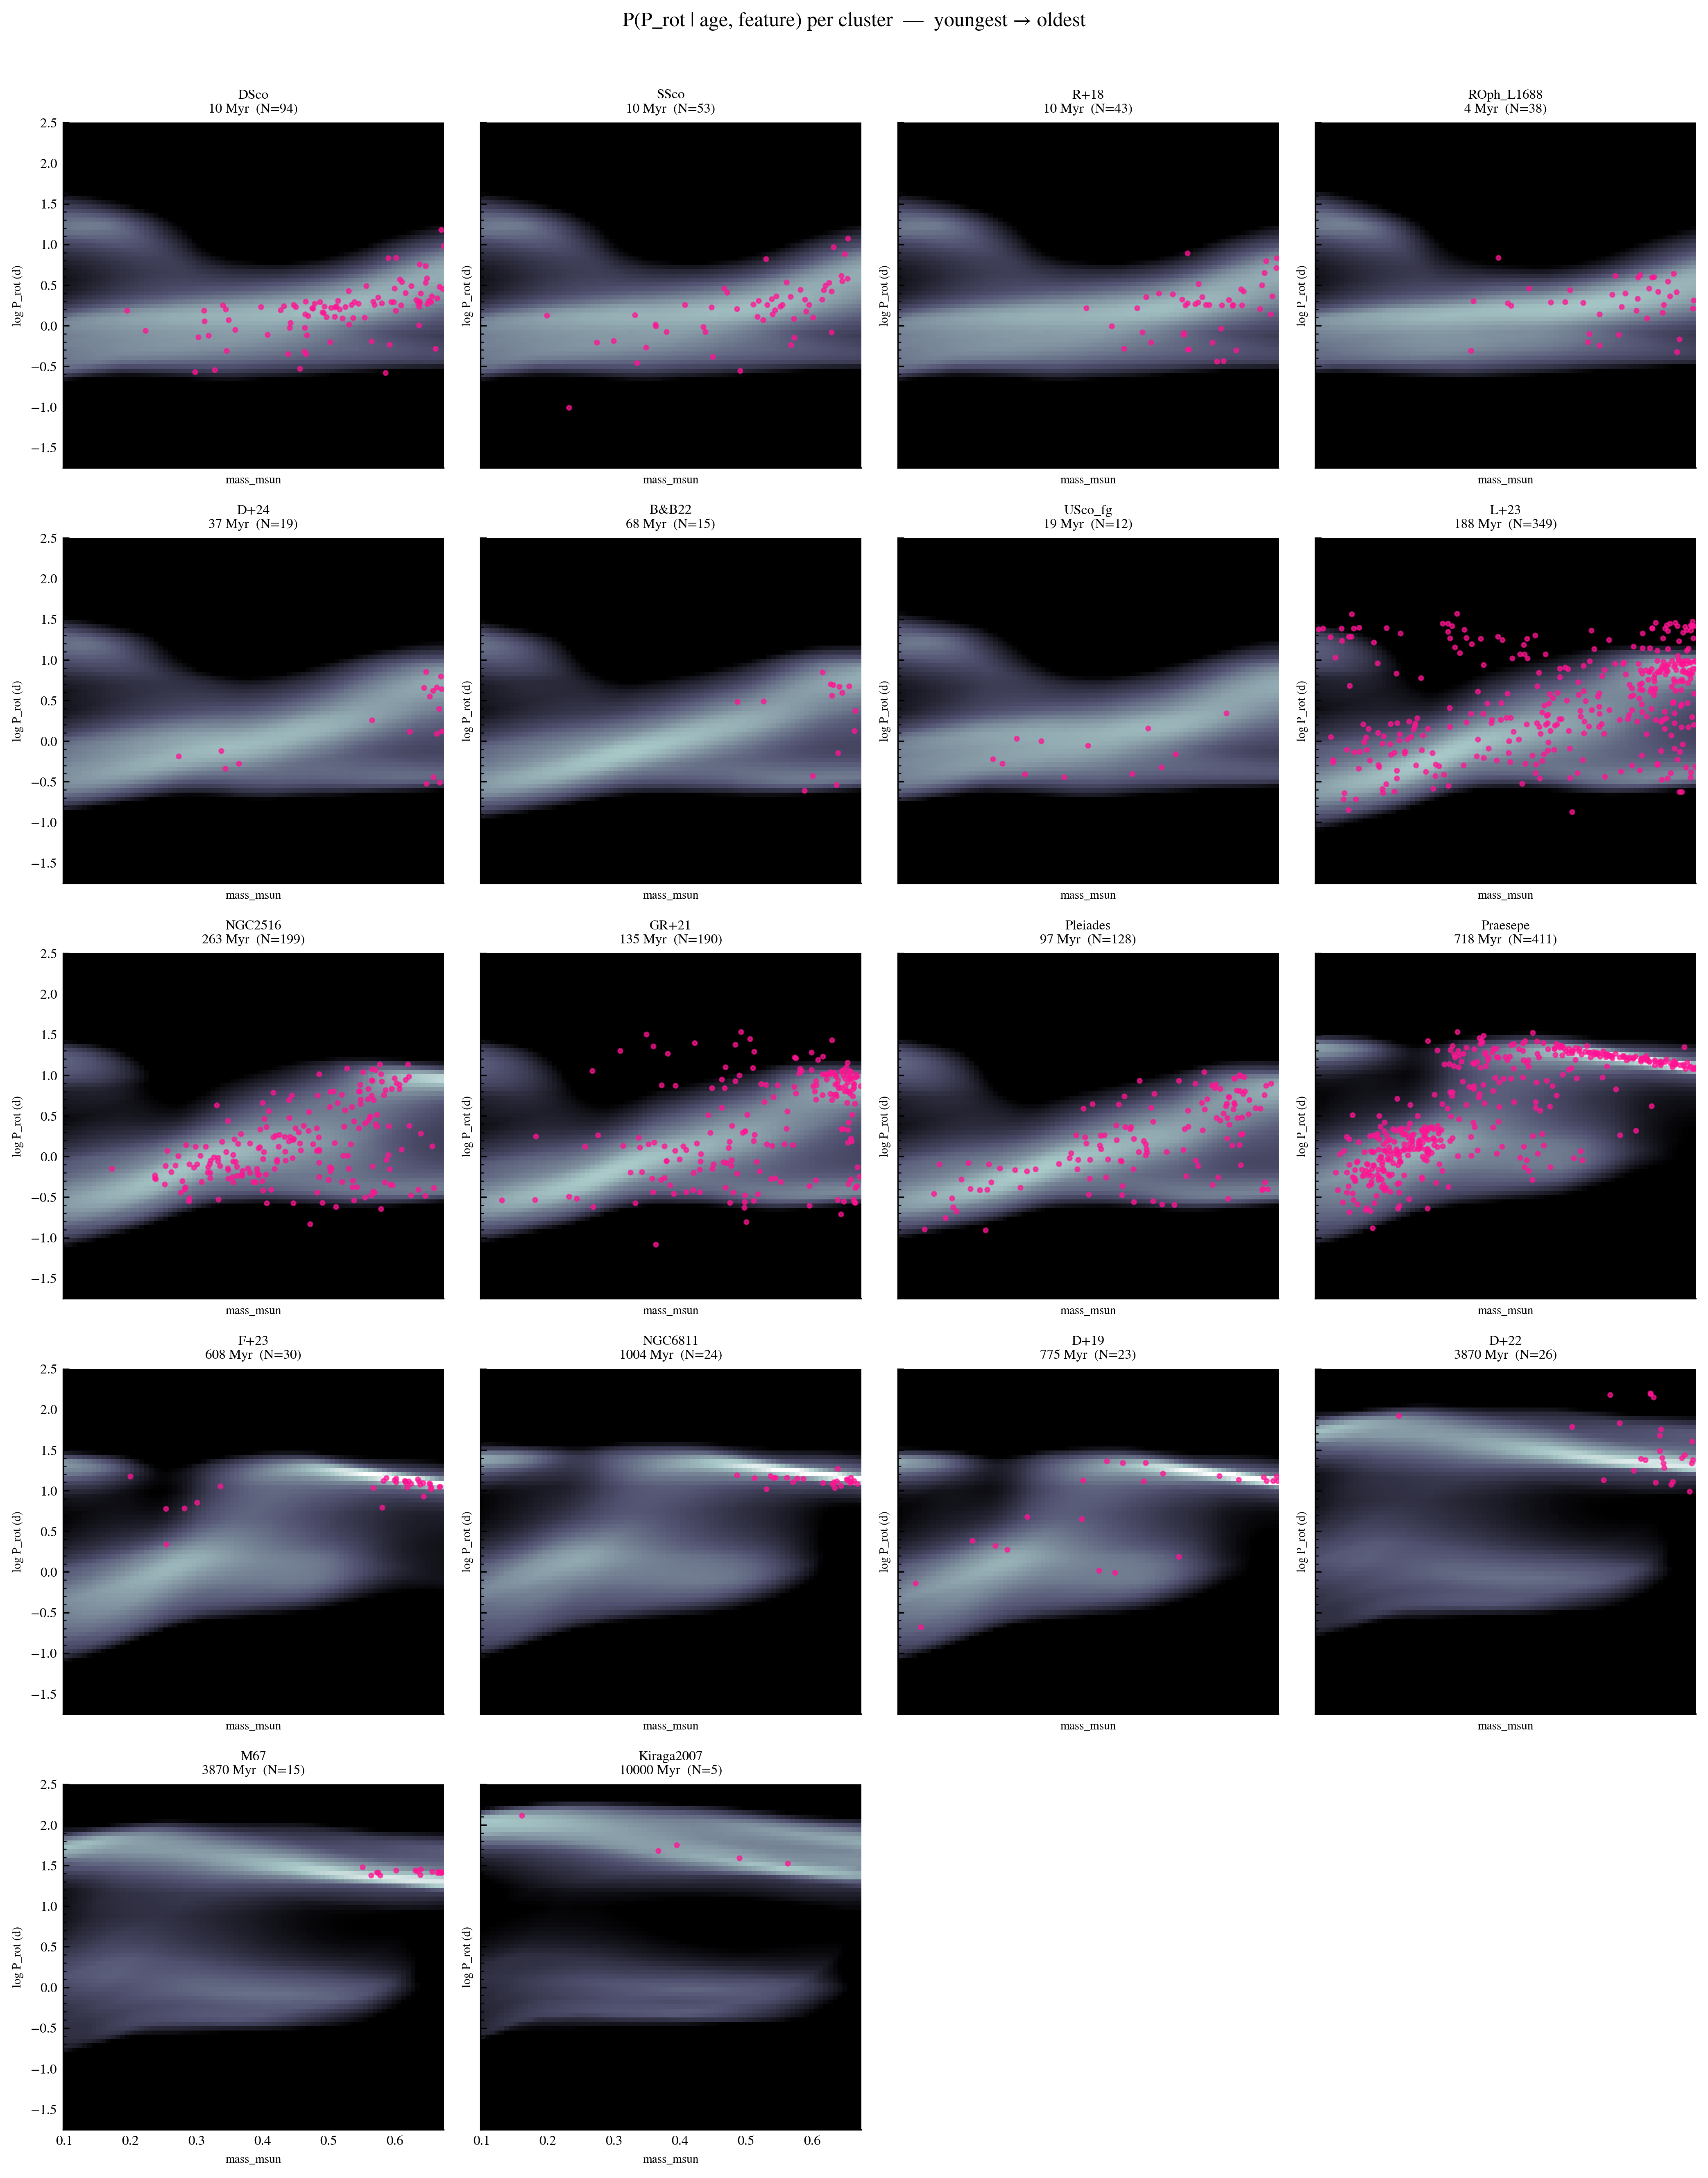

In [ ]:
import importlib, training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import prot_space_report

prot_space_report(best['fold_flows'], train_val_df, COND_COLS, best['fold_scalers'])

## 8. Summary statistics

In [ ]:
results_df = best['results_df']
print(f'=== Best config: {best_name} ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
print()
print('Per-fold test log-likelihoods:')
for i, ll in enumerate(best['test_lls']):
    print(f'  Fold {i}: {ll:.6f}')
print(f'  Mean  : {best["mean_test_ll"]:.6f}')
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== Best config: baseline_b16 ===
N stars evaluated : 5515
Median residual   : -0.282 dex
Median precision  : 1.857 dex
% within 0.3 dex  : 36.5%

Per-fold test log-likelihoods:
  Fold 0: -0.348462
  Fold 1: -0.345928
  Fold 2: -0.356387
  Fold 3: -0.358637
  Fold 4: -0.349310
  Mean  : -0.351745


residual_dex          
           median       std
fold                       
0       -0.300625  0.654292
1       -0.241776  0.670302
2       -0.296539  0.684546
3       -0.274045  0.659602
4       -0.285089  0.646759

In [ ]:
valid = results_df[['log_age_myr', 'p16', 'p84']].notna().all(axis=1)
inside_68 = (
    valid
    & (results_df['log_age_myr'] >= results_df['p16'])
    & (results_df['log_age_myr'] <= results_df['p84'])
)

n         = int(valid.sum())
cover68   = inside_68[valid].mean()
expected  = 0.68
binom_sig = np.sqrt(expected * (1 - expected) / n)
off_sig   = (cover68 - expected) / binom_sig

print('=== 68% posterior coverage check ===')
print(f'N valid stars       : {n}')
print(f'Observed coverage   : {cover68:.3f} ({cover68*100:.1f}%)')
print(f'Expected coverage   : {expected:.3f} +/- {binom_sig:.3f} (binomial 1-sigma)')
print(f'Coverage offset     : {off_sig:+.2f} sigma')
if cover68 < expected - binom_sig:
    print('Interpretation      : under-covering; posteriors too narrow / overconfident.')
elif cover68 > expected + binom_sig:
    print('Interpretation      : over-covering; posteriors too broad / conservative.')
else:
    print('Interpretation      : close to nominal 68% calibration.')

=== 68% posterior coverage check ===
N valid stars       : 5515
Observed coverage   : 0.807 (80.7%)
Expected coverage   : 0.680 +/- 0.006 (binomial 1-sigma)
Coverage offset     : +20.23 sigma
Interpretation      : over-covering; posteriors too broad / conservative.


## 9. Save

In [ ]:
import os

# Save best config outputs
out_dir = f'../../outputs/mass_model/{best_name}'
os.makedirs(out_dir, exist_ok=True)

best['results_df'].to_csv(f'{out_dir}/results.csv', index=False)
np.save(f'{out_dir}/posteriors_kfold.npy', best['posteriors'])
np.save(f'{out_dir}/train_curves.npy',  np.array(best['train_curves'],  dtype=object), allow_pickle=True)
np.save(f'{out_dir}/val_curves.npy',    np.array(best['val_curves'],    dtype=object), allow_pickle=True)
np.save(f'{out_dir}/test_lls.npy',      np.array(best['test_lls']))

for i, (flow, scaler) in enumerate(zip(best['fold_flows'], best['fold_scalers'])):
    torch.save(flow.state_dict(), f'{out_dir}/fold{i}_flow.pt')
    with open(f'{out_dir}/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

# Save comparison table
comparison.to_csv('../../outputs/mass_model/sweep_comparison.csv', index=True)

print(f'Best config saved to outputs/mass_model/{best_name}/')
print(f'Sweep comparison saved to outputs/mass_model/sweep_comparison.csv')

Best config saved to outputs/mass_model/baseline_b16/
Sweep comparison saved to outputs/mass_model/sweep_comparison.csv


## 10. Batch-size sweep with linear LR scaling (2xlayers architecture)

Re-sweep batch sizes for the chosen `2xlayers` architecture, scaling LR linearly with batch size (linear scaling rule: `lr = BASE_LR * batch_size / BASE_BATCH`). Batch size 16 excluded per architecture selection results.

In [5]:
BASE_LR    = 1e-3
BASE_BATCH = 32

SCALED_CONFIGS = [
    dict(
        name            = f'2xlayers_b{b}',
        hidden_features = (64, 64, 64, 64),
        use_onecycle    = True,
        batch_size      = b,
        lr              = BASE_LR * b / BASE_BATCH,
    )
    for b in [32, 64, 128, 256, 512]
]

print(f'2xlayers batch-size sweep (base lr={BASE_LR}, base batch={BASE_BATCH}, linear scaling):')
for cfg in SCALED_CONFIGS:
    print(f"  {cfg['name']:20s}  batch={cfg['batch_size']:4d}  lr={cfg['lr']:.2e}")

2xlayers batch-size sweep (base lr=0.001, base batch=32, linear scaling):
  2xlayers_b32          batch=  32  lr=1.00e-03
  2xlayers_b64          batch=  64  lr=2.00e-03
  2xlayers_b128         batch= 128  lr=4.00e-03
  2xlayers_b256         batch= 256  lr=8.00e-03
  2xlayers_b512         batch= 512  lr=1.60e-02


In [6]:
# Standalone setup — run this if skipping earlier cells
import sys; sys.path.insert(0, '../..')
import numpy as np
import pandas as pd
import torch
import pickle
import os
import matplotlib.pyplot as plt

from training.data   import load_training, make_holdout_split
from training.kfold  import run_kfold
from training.plots  import set_paper_style
set_paper_style()

OBS_COL     = 'log_prot'
COND_COLS   = ['log_age_myr', 'mass_msun', 'mass_msun_err_lo', 'mass_msun_err_hi']
N_FOLDS     = 5
TOTAL_STEPS = 10000
N_SAMPLES   = 10

df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=False)
train_val_df, test_df = make_holdout_split(df, test_frac=0.10)
print(f'Train/val pool: {len(train_val_df)}  |  Test holdout: {len(test_df)}')

Train/val pool: 5515  |  Test holdout: 613


In [7]:
scaled_results = {}

for cfg in SCALED_CONFIGS:
    print(f'\n{"="*60}')
    print(f'Config: {cfg["name"]}')
    print(f'  hidden_features = {cfg["hidden_features"]}')
    print(f'  batch_size      = {cfg["batch_size"]}')
    print(f'  lr              = {cfg["lr"]:.2e}')
    print(f'{"="*60}')

    results_df, fold_flows, fold_scalers, train_curves, val_curves, test_lls, posteriors = run_kfold(
        df              = train_val_df,
        test_df         = test_df,
        obs_col         = OBS_COL,
        cond_cols       = COND_COLS,
        n_folds         = N_FOLDS,
        total_steps     = TOTAL_STEPS,
        batch_size      = cfg['batch_size'],
        lr              = cfg['lr'],
        n_samples       = N_SAMPLES,
        use_onecycle    = cfg['use_onecycle'],
        hidden_features = cfg['hidden_features'],
    )

    scaled_results[cfg['name']] = dict(
        results_df   = results_df,
        fold_flows   = fold_flows,
        fold_scalers = fold_scalers,
        train_curves = train_curves,
        val_curves   = val_curves,
        test_lls     = test_lls,
        posteriors   = posteriors,
        mean_test_ll = float(np.mean(test_lls)),
        lr           = cfg['lr'],
        batch_size   = cfg['batch_size'],
    )


Config: 2xlayers_b32
  hidden_features = (64, 64, 64, 64)
  batch_size      = 32
  lr              = 1.00e-03

=== Fold 1 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.317340)
  test avg log-likelihood: -0.339447

=== Fold 2 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.344455)
  test avg log-likelihood: -0.325388

=== Fold 3 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.350086)
  test avg log-likelihood: -0.357185

=== Fold 4 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.355146)
  test avg log-likelihood: -0.348187

=== Fold 5 / 5 ===
  total_steps=10000  steps_per_epoch=138  epochs=72
  → best checkpoint restored  (val 0.345974)
  test avg log-likelihood: -0.340299

=== Mean test avg log-likelihood across folds: -0.342101 ===

Config: 2xlayers_b64
  hidden_features = (64, 64, 64, 64

          config  batch_size     lr  mean_test_ll    ll_std  median_residual  median_precision
1   2xlayers_b32          32  0.001     -0.342101  0.010528        -0.225771          1.905866
2   2xlayers_b64          64  0.002     -0.350984  0.009235        -0.224403          1.949917
3  2xlayers_b128         128  0.004     -0.355078  0.022077        -0.257883          1.919498
4  2xlayers_b256         256  0.008     -0.359950  0.013162        -0.246065          1.952132
5  2xlayers_b512         512  0.016     -0.360409  0.020002        -0.257755          1.916371

Best config: 2xlayers_b32  (mean test LL = -0.342101)


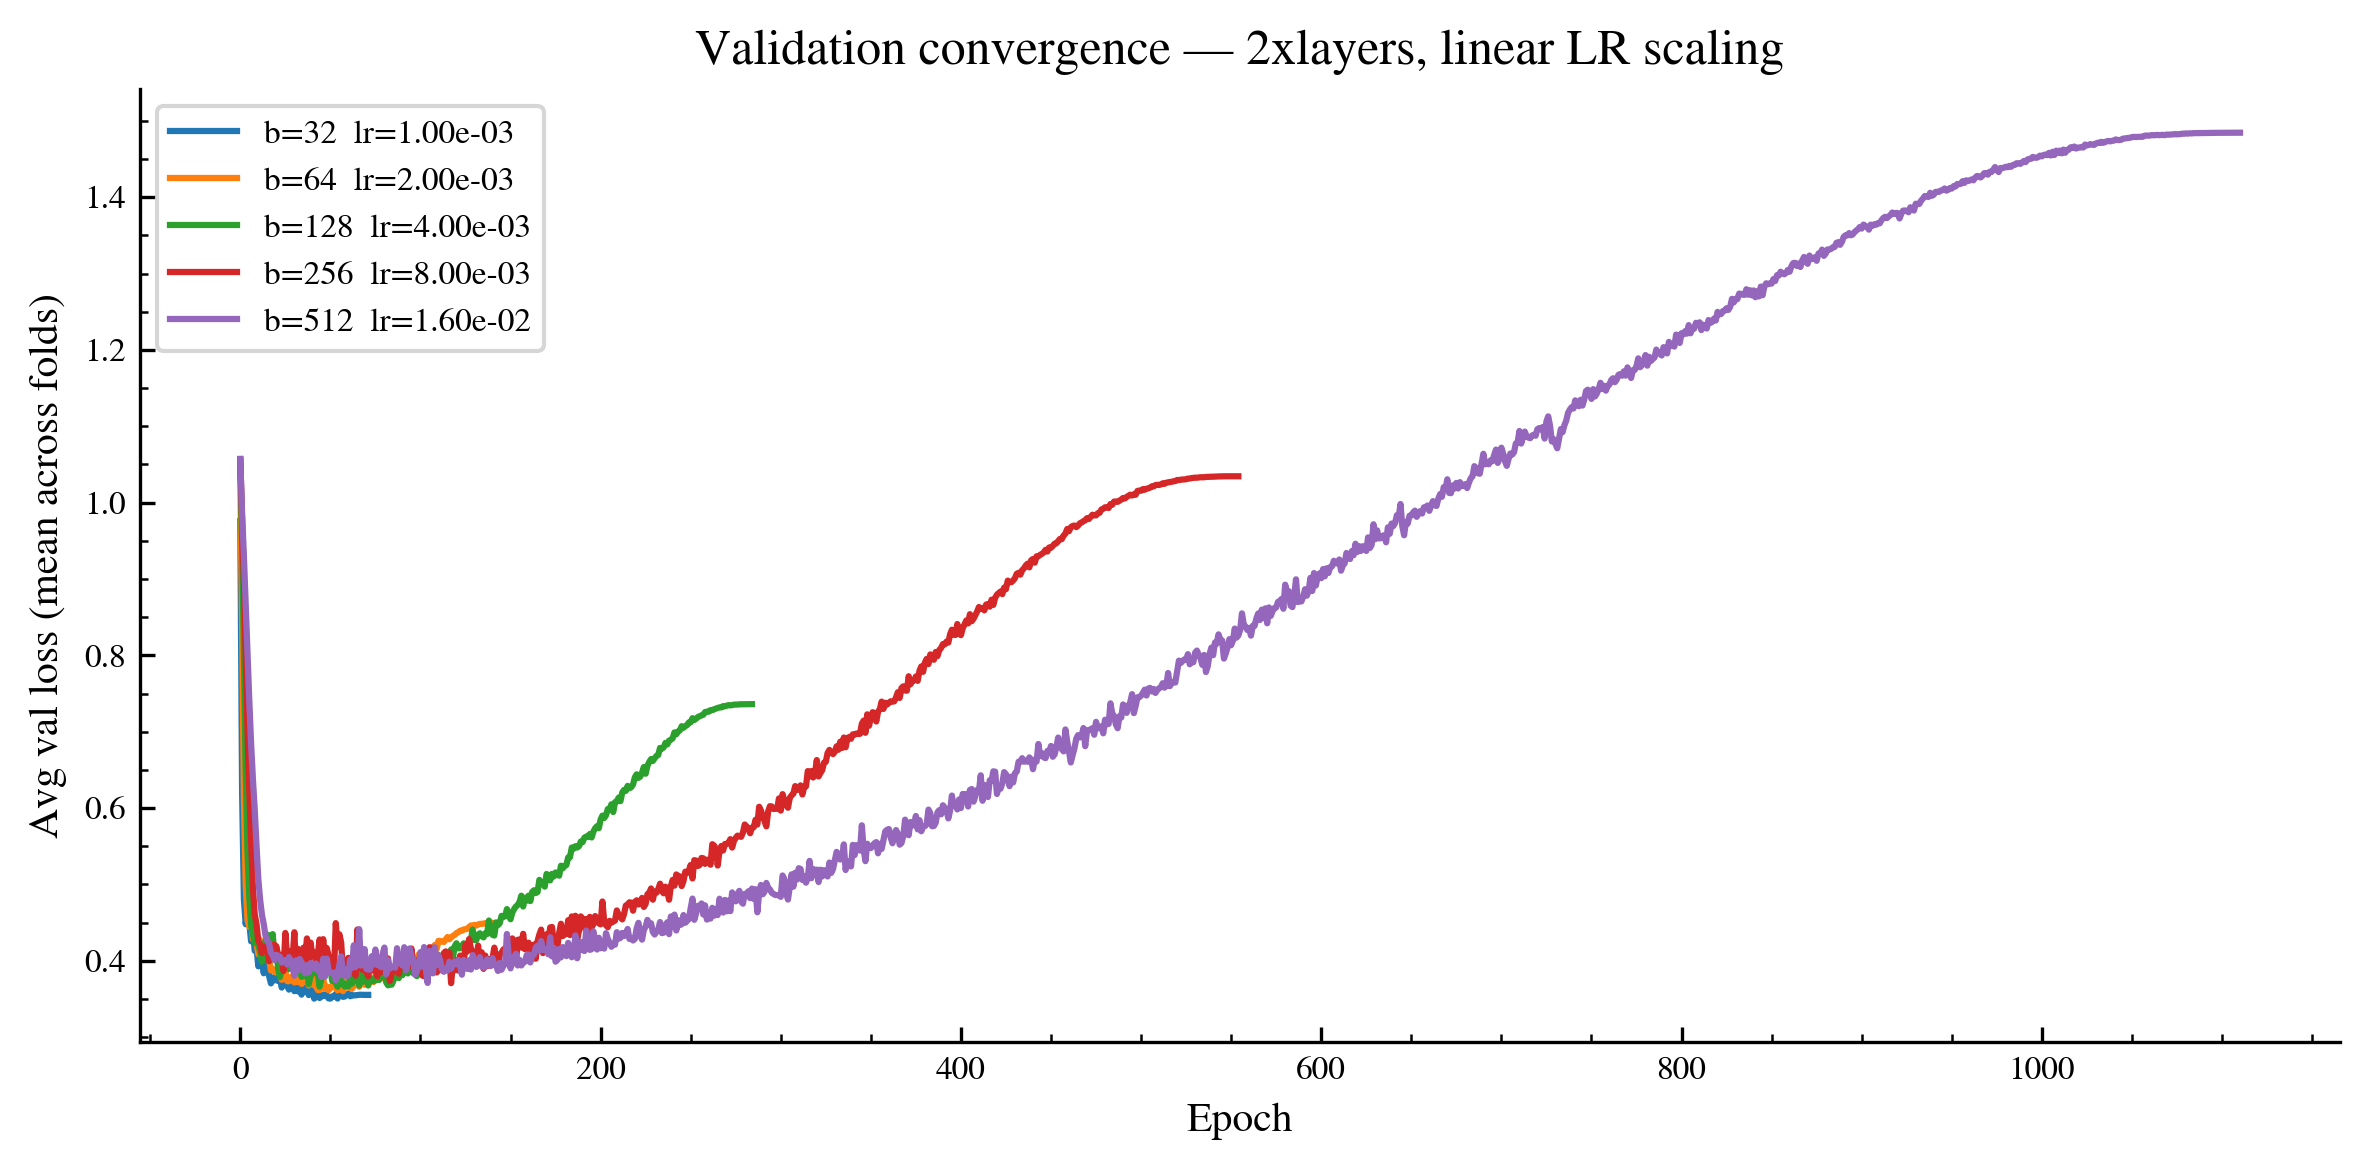

In [8]:
scaled_comparison = pd.DataFrame([
    dict(
        config           = name,
        batch_size       = scaled_results[name]['batch_size'],
        lr               = scaled_results[name]['lr'],
        mean_test_ll     = scaled_results[name]['mean_test_ll'],
        ll_std           = float(np.std(scaled_results[name]['test_lls'])),
        median_residual  = float(scaled_results[name]['results_df']['residual_dex'].median()),
        median_precision = float((scaled_results[name]['results_df']['p84']
                                  - scaled_results[name]['results_df']['p16']).median()),
    )
    for name in scaled_results
]).sort_values('mean_test_ll', ascending=False).reset_index(drop=True)

scaled_comparison.index += 1
print(scaled_comparison.to_string())
print()
best_scaled_name = scaled_comparison.iloc[0]['config']
print(f'Best config: {best_scaled_name}  (mean test LL = {scaled_comparison.iloc[0]["mean_test_ll"]:.6f})')

fig, ax = plt.subplots(figsize=(8, 4))
for name, res in scaled_results.items():
    vc      = res['val_curves']
    min_len = min(len(c) for c in vc)
    avg_val = np.mean([c[:min_len] for c in vc], axis=0)
    ax.plot(avg_val, label=f"b={res['batch_size']}  lr={res['lr']:.2e}", lw=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Avg val loss (mean across folds)')
ax.set_title('Validation convergence — 2xlayers, linear LR scaling')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
best_scaled = scaled_results[best_scaled_name]
out_dir_scaled = f'../../outputs/mass_model/{best_scaled_name}_scaled'
os.makedirs(out_dir_scaled, exist_ok=True)

best_scaled['results_df'].to_csv(f'{out_dir_scaled}/results.csv', index=False)
np.save(f'{out_dir_scaled}/posteriors_kfold.npy', best_scaled['posteriors'])
np.save(f'{out_dir_scaled}/train_curves.npy', np.array(best_scaled['train_curves'], dtype=object), allow_pickle=True)
np.save(f'{out_dir_scaled}/val_curves.npy',   np.array(best_scaled['val_curves'],   dtype=object), allow_pickle=True)
np.save(f'{out_dir_scaled}/test_lls.npy',     np.array(best_scaled['test_lls']))

for i, (flow, scaler) in enumerate(zip(best_scaled['fold_flows'], best_scaled['fold_scalers'])):
    torch.save(flow.state_dict(), f'{out_dir_scaled}/fold{i}_flow.pt')
    with open(f'{out_dir_scaled}/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

scaled_comparison.to_csv('../../outputs/mass_model/scaled_lr_sweep_comparison.csv', index=True)

print(f'Best config saved to outputs/mass_model/{best_scaled_name}_scaled/')
print(f'Comparison table saved to outputs/mass_model/scaled_lr_sweep_comparison.csv')

Best config saved to outputs/mass_model/2xlayers_b32_scaled/
Comparison table saved to outputs/mass_model/scaled_lr_sweep_comparison.csv
